# Experiment 3: Internal Masking vs Occlusion Training

**Goal:** Test whether internal channel masking during training can improve robustness to occlusions, as an alternative to training on occluded images.

**Sessions (6 per model):**
- S1: Clean train (baseline)
- S2: Occluded train (standard practice)
- S3: Clean train + mask backbone_early
- S4: Clean train + mask backbone_late
- S5: Clean train + mask neck
- S6: Clean train + mask head

**Evaluation:**
- All models tested on both `test_clean` and `test_occluded` (40%)
- Using our custom evaluation system (P/R/F1, per-class, counting)

## 0. Configuration

**EDIT THIS CELL to switch between smoke test and full run:**

In [25]:
# ============================================================
# EXPERIMENT 3 CONFIGURATION - EDIT THIS CELL ONLY
# ============================================================

# EPOCHS: Set to 1 for smoke test, 50 for full experiment
EPOCHS = 50  # <-- CHANGE THIS: 1 = smoke test, 50 = full run

# Models to run (both for full experiment, one for quick test)
MODELS = ["yolov8m", "rtdetr-l"]

# Sessions to run (all 6 for full, fewer for quick test)
#SESSIONS_TO_RUN = ["S1_clean_train", "S2_occ_train", "S3_mask_backbone_early",
#                   "S4_mask_backbone_late", "S5_mask_neck", "S6_mask_head"]
SESSIONS_TO_RUN = ["S2_occ_train"]

# Masking parameters (fixed for all sessions)
P_APPLY = 0.3      # Probability of applying masking per batch
P_CHANNELS = 0.1   # Fraction of channels to zero when masking

# Training parameters
IMGSZ = 640
BATCH = -1  # Auto batch size
PATIENCE = 10  # Early stopping patience
SEED = 42  # Fixed seed for reproducibility

# Occlusion level for test
OCCLUSION_LEVEL = "level_040"  # 40% occlusion

# ============================================================
# GOOGLE DRIVE - RUN_ID for resume capability
# ============================================================
# IMPORTANT: Smoke test and full run should use DIFFERENT RUN_IDs!
#
# Option 1: Automatic (recommended)
#   - Each run gets a unique timestamp-based ID
#   - Smoke test won't interfere with full run
#
# Option 2: Manual resume
#   - Set RUN_ID to a specific string to continue a previous run
#
import time
if EPOCHS <= 1:
    # Smoke test: use a fixed ID so it's easy to delete/ignore
    RUN_ID = "E3_SMOKE_TEST"
else:
    # Full run: use timestamp for unique ID
    RUN_ID = time.strftime("E3_%Y%m%d_%H%M%S")

# To RESUME a specific run, uncomment and set:
RUN_ID = "E3_20260122_091602"  # <-- IF YOU WANT TO USE EXISTING RUN: paste your RUN_ID here

# ============================================================
print(f"Configuration:")
print(f"  EPOCHS: {EPOCHS} {'(SMOKE TEST)' if EPOCHS <= 1 else '(FULL RUN)'}")
print(f"  MODELS: {MODELS}")
print(f"  SESSIONS: {len(SESSIONS_TO_RUN)} sessions")
print(f"  Masking: p_apply={P_APPLY}, p_channels={P_CHANNELS}")
print(f"  RUN_ID: {RUN_ID}")
print()
if EPOCHS <= 1:
    print("NOTE: Smoke test uses RUN_ID='E3_SMOKE_TEST'")
    print("      This will NOT interfere with your full 50-epoch run.")
    print("      Full run will get a unique timestamp-based RUN_ID.")

Configuration:
  EPOCHS: 50 (FULL RUN)
  MODELS: ['yolov8m', 'rtdetr-l']
  SESSIONS: 1 sessions
  Masking: p_apply=0.3, p_channels=0.1
  RUN_ID: E3_20260122_091602



## 1. Setup & Mount Google Drive (FIRST!)

**IMPORTANT:** Drive is mounted at the very beginning so you can approve permissions and then leave the computer running overnight.

In [26]:
# Check if in Colab and mount Drive FIRST
import sys
import os
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")

    # ============================================================
    # MOUNT GOOGLE DRIVE FIRST - This will prompt for permission
    # ============================================================
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully!")

    # Clone repo if not already cloned
    if not os.path.exists('/content/Deep_Learning_Gil_Alon'):
        !git clone https://github.com/gil-attar/Deep_Learning_Project_Gil_Alon.git Deep_Learning_Gil_Alon
    os.chdir('/content/Deep_Learning_Gil_Alon')
else:
    print("Running locally - Drive backup not needed")
    if 'Experiment_3' in os.getcwd():
        os.chdir('../..')

print(f"Working directory: {os.getcwd()}")

Running in Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!
Working directory: /content/Deep_Learning_Gil_Alon


## 1.1 Setup Drive Folder Structure (Same as Experiment 1)

In [27]:
from pathlib import Path

PROJECT_NAME = "Deep_Learning_Project_Gil_Alon"

if IN_COLAB:
    # Setup Drive paths (same structure as Experiment 1)
    DRIVE_ROOT = Path("/content/drive/MyDrive/Colab_Outputs") / PROJECT_NAME / RUN_ID
    PERSIST_E3_RUNS = DRIVE_ROOT / "E3_runs"  # Training outputs go here

    PERSIST_E3_RUNS.mkdir(parents=True, exist_ok=True)

    # ============================================================
    # SAVE RUN_ID TO DRIVE (so you can find it later to resume)
    # ============================================================
    run_id_file = DRIVE_ROOT / "RUN_ID.txt"
    run_id_file.write_text(f"{RUN_ID}\n\nTo resume after disconnect:\n1. Set RUN_ID = \"{RUN_ID}\" in config cell\n2. Re-run all cells\n")

    # Also save to a "latest" file for easy lookup
    latest_file = Path("/content/drive/MyDrive/Colab_Outputs") / PROJECT_NAME / "LATEST_E3_RUN_ID.txt"
    latest_file.write_text(f"{RUN_ID}")

    print(f"Drive root: {DRIVE_ROOT}")
    print(f"E3 runs will be saved to: {PERSIST_E3_RUNS}")
    print(f"")
    print(f"========================================")
    print(f"RUN_ID saved to: {run_id_file}")
    print(f"Latest run ID: {latest_file}")
    print(f"========================================")

    # Symlink local runs/ to Drive (so training writes directly to Drive)
    REPO = Path.cwd()
    E3_RUNS_IN_REPO = REPO / "runs" / "exp3"

    # Remove local dir if exists, then symlink to Drive
    !rm -rf "{E3_RUNS_IN_REPO}"
    E3_RUNS_IN_REPO.parent.mkdir(parents=True, exist_ok=True)
    !ln -s "{PERSIST_E3_RUNS}" "{E3_RUNS_IN_REPO}"

    print(f"\nSymlink created: {E3_RUNS_IN_REPO} -> {PERSIST_E3_RUNS}")
else:
    PERSIST_E3_RUNS = None
    print("Running locally - no Drive symlink needed")

Drive root: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602
E3 runs will be saved to: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs

RUN_ID saved to: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/RUN_ID.txt
Latest run ID: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/LATEST_E3_RUN_ID.txt

Symlink created: /content/Deep_Learning_Gil_Alon/runs/exp3 -> /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs


In [28]:
# Install dependencies
!pip install -q ultralytics roboflow pyyaml pillow numpy matplotlib pandas tqdm

In [29]:
# Verify GPU
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA L4


In [30]:
# Imports
from pathlib import Path
import json
import shutil
import yaml
import pandas as pd
from datetime import datetime

from ultralytics import YOLO, RTDETR

# Import our experiment modules
sys.path.insert(0, str(Path.cwd()))
from experiments.Experiment_3.mask_presets import (
    get_mask_prefixes, get_session_config, SESSIONS
)
from experiments.Experiment_3.channel_masking import MaskingManager

# Define output_dir first
output_dir = Path("runs/exp3").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

# Import debug logger and utilities
from experiments.Experiment_3.debug_logger import (
    ExperimentDebugLogger,
    verify_data_yaml,
    verify_labels_exist,
    verify_occluded_test_data,
    get_environment_info,
    analyze_prediction_confidences
)
from experiments.Experiment_3.channel_masking import MaskingManager
from PIL import Image
import glob

DEBUG_LOG_DIR = output_dir / "debug_logs"
debug_logger = ExperimentDebugLogger(DEBUG_LOG_DIR, RUN_ID)
print(f"Debug logs will be saved to: {DEBUG_LOG_DIR}")

env_info = get_environment_info()
debug_logger.log_environment(env_info)
print(f"GPU: {env_info.get('gpu_name', 'N/A')}")

print("All imports successful!")

Debug logs will be saved to: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs/debug_logs
GPU: NVIDIA L4
All imports successful!


## 2. Download Dataset

In [31]:
# Download dataset if not exists
if not Path("data/raw/train/images").exists():
    os.environ["ROBOFLOW_API_KEY"] = "zEF9icmDY2oTcPkaDcQY"
    !python scripts/download_dataset.py --output_dir data/raw
else:
    print("Dataset already exists")

# Verify
print(f"Train images: {len(list(Path('data/raw/train/images').glob('*')))}")
print(f"Val images: {len(list(Path('data/raw/valid/images').glob('*')))}")
print(f"Test images: {len(list(Path('data/raw/test/images').glob('*')))}")

Dataset already exists
Train images: 1384
Val images: 200
Test images: 400


## 3. Build Evaluation Indices & Generate Occluded Data

**IMPORTANT:** All sessions use the SAME dataset splits and SAME occluded test images (fixed seed=42).

In [32]:
# Build evaluation indices (same for ALL sessions)
# We need BOTH test_index.json AND train_index.json (for generating occluded training data)

indices_exist = (
    Path("data/processed/evaluation/test_index.json").exists() and
    Path("data/processed/evaluation/train_index.json").exists()
)

if not indices_exist:
    print("Building evaluation indices for all splits...")
    !python scripts/build_evaluation_indices.py \
        --dataset_root data/raw \
        --output_dir data/processed/evaluation
else:
    print("Evaluation indices already exist")

# Verify both exist
assert Path("data/processed/evaluation/test_index.json").exists(), "test_index.json not found!"
assert Path("data/processed/evaluation/train_index.json").exists(), "train_index.json not found!"

with open("data/processed/evaluation/test_index.json") as f:
    test_index = json.load(f)
print(f"Test set: {test_index['metadata']['num_images']} images, {test_index['metadata']['total_objects']} objects")

with open("data/processed/evaluation/train_index.json") as f:
    train_index = json.load(f)
print(f"Train set: {train_index['metadata']['num_images']} images, {train_index['metadata']['total_objects']} objects")

Evaluation indices already exist
Test set: 400 images, 856 objects
Train set: 1384 images, 3114 objects


In [33]:
# Generate occluded TRAINING data for S2 (seed=42 for reproducibility)
occluded_train_dir = Path("data/occluded_train_040/level_040")

if not occluded_train_dir.exists():
    print("Generating occluded training data (40% occlusion, seed=42)...")
    !python scripts/generate_synthetic_occlusions.py \
        --test_index data/processed/evaluation/train_index.json \
        --images_dir data/raw/train/images \
        --labels_dir data/raw/train/labels \
        --output_dir data/occluded_train_040 \
        --levels 0.4 \
        --seed 42
else:
    print(f"Occluded training data already exists at {occluded_train_dir}")

Occluded training data already exists at data/occluded_train_040/level_040


In [34]:
# Generate occluded TEST data (seed=42 - SAME for all sessions!)
occluded_test_dir = Path(f"data/synthetic_occlusion/{OCCLUSION_LEVEL}")

if not occluded_test_dir.exists():
    print(f"Generating occluded test data ({OCCLUSION_LEVEL}, seed=42)...")
    !python scripts/generate_synthetic_occlusions.py \
        --test_index data/processed/evaluation/test_index.json \
        --images_dir data/raw/test/images \
        --labels_dir data/raw/test/labels \
        --output_dir data/synthetic_occlusion \
        --levels 0.4 \
        --seed 42
else:
    print(f"Occluded test data already exists at {occluded_test_dir}")

print(f"\nAll sessions will use:")
print(f"  - Same train images: data/raw/train/")
print(f"  - Same occluded train (S2 only): {occluded_train_dir}")
print(f"  - Same test images: data/raw/test/")
print(f"  - Same occluded test: {occluded_test_dir}")

Occluded test data already exists at data/synthetic_occlusion/level_040

All sessions will use:
  - Same train images: data/raw/train/
  - Same occluded train (S2 only): data/occluded_train_040/level_040
  - Same test images: data/raw/test/
  - Same occluded test: data/synthetic_occlusion/level_040


## 4. Create Data YAML Files

In [35]:
# Create data.yaml files for clean and occluded training

# Load class names from original data.yaml
with open('data/raw/data.yaml', 'r') as f:
    original_config = yaml.safe_load(f)

# Clean training data.yaml (for S1, S3-S6)
clean_config = {
    'path': str(Path('data/raw').resolve()),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'names': original_config['names'],
    'nc': len(original_config['names'])
}

Path('data/processed').mkdir(parents=True, exist_ok=True)
with open('data/processed/data_clean.yaml', 'w') as f:
    yaml.dump(clean_config, f, default_flow_style=False)
print("Created data/processed/data_clean.yaml")

# Occluded training data.yaml (for S2 only)
occ_train_config = {
    'path': str(Path('data').resolve()),
    'train': 'occluded_train_040/level_040/images',
    'val': 'raw/valid/images',
    'test': 'raw/test/images',
    'names': original_config['names'],
    'nc': len(original_config['names'])
}

with open('data/processed/data_occ_train.yaml', 'w') as f:
    yaml.dump(occ_train_config, f, default_flow_style=False)
print("Created data/processed/data_occ_train.yaml")

Created data/processed/data_clean.yaml
Created data/processed/data_occ_train.yaml


DATA VERIFICATION (CRITICAL - CHECK THESE BEFORE RUNNING FULL EXPERIMENT)
\n1. CLEAN TRAINING DATA:
   Path: /content/Deep_Learning_Gil_Alon/data/raw/train/images
   Exists: True
   Images: 1384
   Sample: ['/content/Deep_Learning_Gil_Alon/data/raw/train/images/-113_jpg.rf.61ed4e62855aafc07238d2973ef5e8e8.jpg', '/content/Deep_Learning_Gil_Alon/data/raw/train/images/-131_jpg.rf.76a6ffefe152c582fe95c86645c1b94f.jpg', '/content/Deep_Learning_Gil_Alon/data/raw/train/images/download-8-_jpg.rf.aefae9e9fe2b5fa630ff19a191e78187.jpg']
   Labels dir exists: True
   Total boxes: 3114
   Missing labels: 0
\n2. OCCLUDED TRAINING DATA (S2):
   Path: /content/Deep_Learning_Gil_Alon/data/occluded_train_040/level_040/images
   Exists: True
   Images: 1384
   Sample: ['/content/Deep_Learning_Gil_Alon/data/occluded_train_040/level_040/images/-113_jpg.rf.61ed4e62855aafc07238d2973ef5e8e8.jpg', '/content/Deep_Learning_Gil_Alon/data/occluded_train_040/level_040/images/-131_jpg.rf.76a6ffefe152c582fe95c86645c1

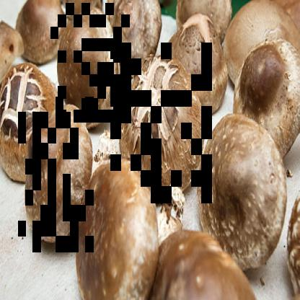

   Displaying: data/occluded_train_040/level_040/images/-131_jpg.rf.76a6ffefe152c582fe95c86645c1b94f.jpg


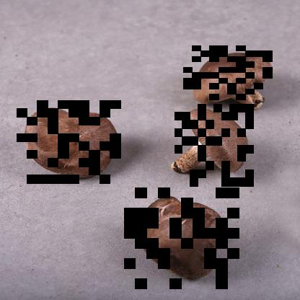

   Displaying: data/occluded_train_040/level_040/images/download-8-_jpg.rf.aefae9e9fe2b5fa630ff19a191e78187.jpg


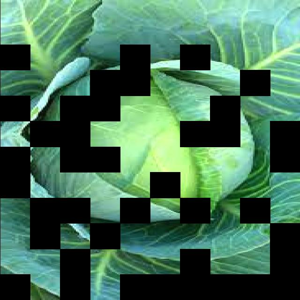

\n5. SIDE-BY-SIDE COMPARISON (Clean vs Occluded):
   Clean: data/raw/train/images/-113_jpg.rf.61ed4e62855aafc07238d2973ef5e8e8.jpg
   Occluded: /content/Deep_Learning_Gil_Alon/data/occluded_train_040/level_040/images/-113_jpg.rf.61ed4e62855aafc07238d2973ef5e8e8.jpg


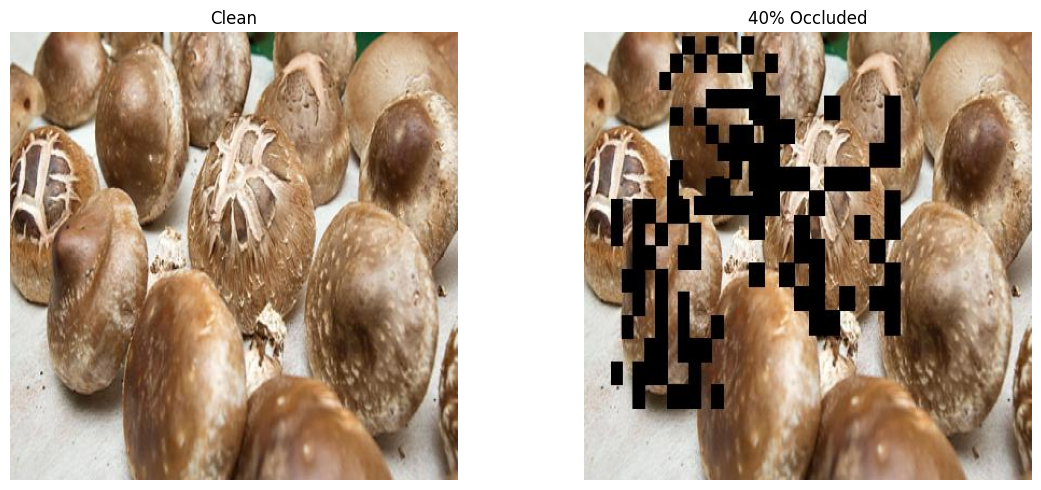

\n======================================================================
SANITY CHECK SUMMARY:
All checks passed! Safe to proceed with training.


In [36]:
import matplotlib.pyplot as plt
print("="*70)
print("DATA VERIFICATION (CRITICAL - CHECK THESE BEFORE RUNNING FULL EXPERIMENT)")
print("="*70)

# Verify clean training data
print("\\n1. CLEAN TRAINING DATA:")
clean_info = verify_data_yaml("data/processed/data_clean.yaml")
print(f"   Path: {clean_info['train_path']}")
print(f"   Exists: {clean_info['train_exists']}")
print(f"   Images: {clean_info['num_train_images']}")
print(f"   Sample: {clean_info['sample_train_images'][:3]}")

# Verify labels for clean training data
clean_labels = verify_labels_exist("data/raw/train/images")
print(f"   Labels dir exists: {clean_labels['labels_dir_exists']}")
print(f"   Total boxes: {clean_labels['total_boxes']}")
print(f"   Missing labels: {clean_labels['num_missing_labels']}")

# Verify occluded training data
print("\\n2. OCCLUDED TRAINING DATA (S2):")
occ_info = verify_data_yaml("data/processed/data_occ_train.yaml")
print(f"   Path: {occ_info['train_path']}")
print(f"   Exists: {occ_info['train_exists']}")
print(f"   Images: {occ_info['num_train_images']}")
print(f"   Sample: {occ_info['sample_train_images'][:3]}")

# Verify labels for occluded training data
occ_labels = verify_labels_exist("data/occluded_train_040/level_040/images")
print(f"   Labels dir exists: {occ_labels['labels_dir_exists']}")
print(f"   Total boxes: {occ_labels['total_boxes']}")
print(f"   Missing labels: {occ_labels['num_missing_labels']}")

if occ_labels['num_missing_labels'] > 0:
    print(f"   *** CRITICAL: S2 has {occ_labels['num_missing_labels']} images without labels! ***")

# Verify occluded test data
print("\\n3. OCCLUDED TEST DATA:")
occ_test = verify_occluded_test_data("data/synthetic_occlusion/level_040")
print(f"   Path: {occ_test['path']}")
print(f"   Exists: {occ_test['exists']}")
print(f"   Images: {occ_test.get('num_images', 0)}")
print(f"   Labels: {occ_test.get('num_labels', 0)}")

# Check if occluded images LOOK occluded (display a few)
print("\\n4. VISUAL INSPECTION OF OCCLUDED TRAINING IMAGES:")
occ_train_images = glob.glob("data/occluded_train_040/level_040/images/*.jpg")[:3]
if occ_train_images:
    for img_path in occ_train_images:
        print(f"   Displaying: {img_path}")
        display(Image.open(img_path).resize((300, 300)))
else:
    print("   *** WARNING: No occluded training images found! ***")

# Compare clean vs occluded image of same file
print("\\n5. SIDE-BY-SIDE COMPARISON (Clean vs Occluded):")
if occ_info['sample_train_images']:
    occ_sample = Path(occ_info['sample_train_images'][0])
    clean_sample = Path("data/raw/train/images") / occ_sample.name
    if clean_sample.exists():
        print(f"   Clean: {clean_sample}")
        print(f"   Occluded: {occ_sample}")
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(Image.open(clean_sample))
        axes[0].set_title("Clean")
        axes[0].axis('off')
        axes[1].imshow(Image.open(occ_sample))
        axes[1].set_title("40% Occluded")
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()

print("\\n" + "="*70)
print("SANITY CHECK SUMMARY:")
print("="*70)
issues = []
if not clean_info['train_exists']:
    issues.append("Clean training images not found!")
if not occ_info['train_exists']:
    issues.append("Occluded training images not found!")
if occ_labels['num_missing_labels'] > 0:
    issues.append(f"Occluded training missing {occ_labels['num_missing_labels']} labels!")
if not occ_test['exists']:
    issues.append("Occluded test data not found!")

if issues:
    print("*** ISSUES FOUND - DO NOT PROCEED UNTIL FIXED: ***")
    for issue in issues:
        print(f"  - {issue}")
else:
    print("All checks passed! Safe to proceed with training.")
print("="*70)

## 5. Training Functions

In [37]:
def get_model(model_name: str):
    """Load a model by name."""
    if 'yolo' in model_name.lower():
        return YOLO(f"{model_name}.pt")
    elif 'rtdetr' in model_name.lower():
        return RTDETR(f"{model_name}.pt")
    else:
        raise ValueError(f"Unknown model: {model_name}")


def get_model_type(model_name: str) -> str:
    """Get model type for mask presets."""
    if 'yolo' in model_name.lower():
        return 'yolo'
    elif 'rtdetr' in model_name.lower():
        return 'rtdetr'
    else:
        raise ValueError(f"Unknown model: {model_name}")


def is_session_complete(output_dir: Path, model_name: str, session_name: str) -> bool:
    """Check if a session is already complete (has DONE marker and weights)."""
    run_dir = output_dir / f"{model_name}__{session_name}"
    done_marker = run_dir / "DONE"
    weights_file = run_dir / "weights" / "best.pt"
    return done_marker.exists() and weights_file.exists()

# Import the new callback-based masking
from experiments.Experiment_3.channel_masking import MaskingCallbacks

def train_session_debug(
    model_name: str,
    session_name: str,
    epochs: int,
    output_dir: Path,
    debug_logger: ExperimentDebugLogger,
    p_apply: float = 0.5,
    p_channels: float = 0.2,
    verbose_masking: bool = True
) -> dict:
    """
    Train a single session with comprehensive debug logging.

    FIXED: Uses callback-based masking that hooks into trainer.model
    (the actual model used for forward passes during training).
    """
    import time
    session_config = get_session_config(session_name)
    run_name = f"{model_name}__{session_name}"
    run_dir = output_dir / run_name

    print(f"\\n{'='*60}")
    print(f"TRAINING: {run_name}")
    print(f"{'='*60}")
    print(f"Description: {session_config['description']}")
    print(f"Epochs: {epochs}")

    # Start debug logging
    debug_logger.start_session(model_name, session_name)

    # Check if already completed
    if is_session_complete(output_dir, model_name, session_name):
        print(f"Session already completed. Skipping.")
        debug_logger.log_warning("Session skipped - already complete")
        debug_logger.end_session(success=True)
        return {"status": "skipped", "run_dir": str(run_dir)}

    # Select data.yaml based on session
    if session_config['train_data'] == 'occluded':
        data_yaml = 'data/processed/data_occ_train.yaml'
    else:
        data_yaml = 'data/processed/data_clean.yaml'

    print(f"Data: {data_yaml}")

    # Log data configuration
    try:
        data_info = verify_data_yaml(data_yaml)
        debug_logger.log_data_config(
            data_yaml_path=data_yaml,
            train_images_dir=data_info['train_path'],
            sample_images=data_info['sample_train_images'],
            num_train_images=data_info['num_train_images'],
            num_val_images=data_info['num_val_images']
        )

        # CRITICAL CHECK: Are we using the right images?
        if session_config['train_data'] == 'occluded':
            if 'occluded' not in data_info['train_path'].lower() and 'occ' not in data_info['train_path'].lower():
                debug_logger.log_warning(f"S2 should use occluded data but train_path is: {data_info['train_path']}")
    except Exception as e:
        debug_logger.log_error(f"Failed to verify data.yaml: {e}")

    # Load model
    model = get_model(model_name)

    # Log model architecture (first time only)
    if session_name == "S1_clean_train":
        debug_logger.log_model_architecture_check(model_name, model.model)

    # Setup CALLBACK-BASED masking if needed
    # This is the FIX - hooks are added via callbacks to trainer.model
    masking_callbacks = None
    mask_location = session_config['mask_location']

    if mask_location is not None:
        model_type = get_model_type(model_name)
        layer_prefixes = get_mask_prefixes(model_type, mask_location)

        print(f"Masking: {mask_location} -> layers {layer_prefixes}")
        print(f"Masking params: p_apply={p_apply}, p_channels={p_channels}")
        print(f"Using CALLBACK-BASED masking (hooks trainer.model)")

        # Create callbacks and register with model
        masking_callbacks = MaskingCallbacks(
            layer_prefixes=layer_prefixes,
            p_apply=p_apply,
            p_channels=p_channels,
            verbose=verbose_masking
        )
        masking_callbacks.register(model)

        # Log config (hooks will be added when training starts)
        debug_logger.log_masking_config(
            enabled=True,
            mask_location=mask_location,
            layer_prefixes=layer_prefixes,
            p_apply=p_apply,
            p_channels=p_channels,
            num_hooks_added=-1,  # Will be set when callbacks fire
            hooked_layer_names=[]  # Will be populated when callbacks fire
        )
    else:
        print("Masking: None")
        debug_logger.log_masking_config(
            enabled=False,
            mask_location=None,
            layer_prefixes=[],
            p_apply=p_apply,
            p_channels=p_channels,
            num_hooks_added=0,
            hooked_layer_names=[]
        )

    # Train with timing
    abs_output_dir = output_dir.resolve()
    start_time = time.time()

    try:
        results = model.train(
            data=data_yaml,
            epochs=epochs,
            imgsz=IMGSZ,
            batch=BATCH,
            patience=PATIENCE,
            save=True,
            project=str(abs_output_dir),
            name=run_name,
            exist_ok=True,
            pretrained=True,
            optimizer='auto',
            verbose=True,
            seed=SEED
        )

        training_time = time.time() - start_time

        # Get masking stats from callbacks
        run_dir = abs_output_dir / run_name
        run_dir.mkdir(parents=True, exist_ok=True)

        if masking_callbacks:
            # Callbacks print summary automatically via on_train_end
            stats = masking_callbacks.get_stats()
            if stats:
                debug_logger.log_masking_summary(
                    total_activations=stats['aggregate']['total_mask_applications'],
                    hooked_layers_summary=stats['per_hook']
                )

                # Save detailed stats to file
                with open(run_dir / "masking_detailed_stats.json", 'w') as f:
                    json.dump(stats, f, indent=2)

                # Save summary
                manager = masking_callbacks.get_manager()
                if manager:
                    with open(run_dir / "masking_summary.json", 'w') as f:
                        json.dump(manager.get_summary(), f, indent=2)
            else:
                debug_logger.log_warning("Masking callbacks did not return stats!")

        # Mark as done
        (run_dir / "DONE").touch()

        debug_logger.log_training_complete(
            weights_path=str(run_dir / "weights" / "best.pt"),
            training_time_seconds=training_time
        )
        debug_logger.end_session(success=True)

        print(f"\\nTraining complete: {run_name}")
        print(f"Time: {training_time:.1f}s")
        print(f"Saved to: {run_dir}")

        return {
            "status": "success",
            "run_dir": str(run_dir),
            "weights_path": str(run_dir / "weights" / "best.pt")
        }

    except Exception as e:
        debug_logger.log_error(f"Training failed: {e}", e)
        debug_logger.end_session(success=False)

        print(f"\\nTraining FAILED: {run_name}")
        print(f"Error: {e}")

        run_dir = abs_output_dir / run_name
        run_dir.mkdir(parents=True, exist_ok=True)
        (run_dir / "FAILED").write_text(str(e))

        return {"status": "failed", "error": str(e), "run_dir": str(run_dir)}

    finally:
        # Cleanup hooks
        if masking_callbacks:
            masking_callbacks.remove_hooks()


print("Training functions defined!")

Training functions defined!


## 6. Run All Training Sessions

In [38]:
# Run all training sessions
# Output goes directly to Drive via symlink (crash-safe!)

output_dir = Path("runs/exp3").resolve()  # Use absolute path
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {output_dir}")
if IN_COLAB:
    print(f"(Symlinked to Drive: {PERSIST_E3_RUNS})")

# Check for existing completed sessions
print("\nChecking for previously completed sessions...")
for model_name in MODELS:
    for session_name in SESSIONS_TO_RUN:
        if is_session_complete(output_dir, model_name, session_name):
            print(f"  Found: {model_name}__{session_name}")

# Run all training sessions with debug logging
training_results = []
total_sessions = len(MODELS) * len(SESSIONS_TO_RUN)
current = 0

for model_name in MODELS:
    for session_name in SESSIONS_TO_RUN:
        current += 1
        print(f"\\n[{current}/{total_sessions}] {model_name} - {session_name}")

        result = train_session_debug(
            model_name=model_name,
            session_name=session_name,
            epochs=EPOCHS,
            output_dir=output_dir,
            debug_logger=debug_logger,
            p_apply=P_APPLY,
            p_channels=P_CHANNELS,
            verbose_masking=(EPOCHS <= 5)  # Only verbose for smoke tests
        )

        result['model'] = model_name
        result['session'] = session_name
        training_results.append(result)

# Finalize debug log
debug_logger.finalize()

# Summary
print("\\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
for r in training_results:
    status_icon = "OK" if r['status'] == 'success' else "SKIP" if r['status'] == 'skipped' else "FAIL"
    print(f"[{status_icon}] {r['model']}__{r['session']}")

print(f"\\nDebug logs saved to: {DEBUG_LOG_DIR}")
print(f"  - debug_log.json (for analysis)")
print(f"  - debug_log.txt (human readable)")

# Save results
with open(output_dir / "training_results.json", 'w') as f:
    json.dump(training_results, f, indent=2)

Output directory: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs
(Symlinked to Drive: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs)

Checking for previously completed sessions...
  Found: yolov8m__S2_occ_train
  Found: rtdetr-l__S2_occ_train
\n[1/2] yolov8m - S2_occ_train
\n============================================================
TRAINING: yolov8m__S2_occ_train
Description: Standard: train on occluded images
Epochs: 50
Session already completed. Skipping.
\n[2/2] rtdetr-l - S2_occ_train
\n============================================================
TRAINING: rtdetr-l__S2_occ_train
Description: Standard: train on occluded images
Epochs: 50
Session already completed. Skipping.

Debug logs saved to:
  JSON: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs/debug_logs/debug_log.json
  Text: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Proj

In [39]:
# DEBUG CELL - WILL CRUSH IF RUNTIME WAS DISCONNECTED. NOT AFFECTING ACTUAL RESULTS.
print("="*70)
print("POST-TRAINING DEBUG ANALYSIS")
print("="*70)

# Load and analyze debug log
with open(DEBUG_LOG_DIR / "debug_log.json") as f:
    debug_data = json.load(f)

print("\\n1. MASKING ACTIVATION CHECK:")
print("-"*50)
for session_key, session in debug_data["sessions"].items():
    if session.get("masking_enabled"):
        total_activations = session.get("masking_final_summary", {}).get("total_activations", 0)
        if total_activations == 0:
            print(f"  [FAIL] {session_key}: Masking enabled but 0 activations!")
        else:
            print(f"  [OK]   {session_key}: {total_activations:,} mask activations")
    else:
        print(f"  [N/A]  {session_key}: No masking (baseline or S2)")

print("\\n2. DATA PATH CHECK:")
print("-"*50)
for session_key, session in debug_data["sessions"].items():
    train_dir = session.get("train_images_dir", "unknown")
    num_images = session.get("num_train_images", 0)
    is_s2 = "S2" in session_key

    if is_s2:
        if "occluded" in train_dir.lower() or "occ" in train_dir.lower():
            print(f"  [OK]   {session_key}: Using occluded data ({num_images} images)")
        else:
            print(f"  [FAIL] {session_key}: S2 should use occluded but using: {train_dir}")
    else:
        if "raw" in train_dir.lower():
            print(f"  [OK]   {session_key}: Using clean data ({num_images} images)")
        else:
            print(f"  [WARN] {session_key}: Using {train_dir}")

print("\\n3. WARNINGS:")
print("-"*50)
if debug_data.get("warnings"):
    for w in debug_data["warnings"]:
        print(f"  - [{w['time']}] {w['message']}")
else:
    print("  No warnings")

print("\\n4. ERRORS:")
print("-"*50)
if debug_data.get("errors"):
    for e in debug_data["errors"]:
        print(f"  - [{e['time']}] {e['message']}")
else:
    print("  No errors")

print("="*70)

POST-TRAINING DEBUG ANALYSIS
\n1. MASKING ACTIVATION CHECK:
--------------------------------------------------
  [N/A]  yolov8m__S2_occ_train: No masking (baseline or S2)
  [N/A]  rtdetr-l__S2_occ_train: No masking (baseline or S2)
\n2. DATA PATH CHECK:
--------------------------------------------------


AttributeError: 'NoneType' object has no attribute 'lower'

## 7. Evaluation Functions

In [40]:
# Import evaluation modules
from evaluation.io import load_ground_truth, load_class_names
from evaluation.metrics import (
    eval_detection_prf_at_iou,
    eval_per_class_metrics_and_confusions,
    eval_counting_quality
)
from evaluation.plots import plot_all_metrics
from tqdm import tqdm


def generate_predictions(model_path: str, test_images_dir: str, test_index: dict) -> list:
    """Generate predictions for a trained model on a test set."""
    # Load model based on path
    if 'rtdetr' in model_path.lower():
        model = RTDETR(model_path)
    else:
        model = YOLO(model_path)

    predictions = []
    test_images_dir = Path(test_images_dir)

    for img_data in tqdm(test_index['images'], desc="Inference"):
        image_path = test_images_dir / img_data['image_filename']

        if not image_path.exists():
            continue

        results = model.predict(
            source=str(image_path),
            conf=0.01,
            imgsz=640,
            verbose=False
        )[0]

        detections = []
        if len(results.boxes) > 0:
            for i in range(len(results.boxes)):
                detections.append({
                    "class_id": int(results.boxes.cls[i].item()),
                    "class_name": results.names[int(results.boxes.cls[i].item())],
                    "confidence": float(results.boxes.conf[i].item()),
                    "bbox": results.boxes.xyxy[i].tolist(),
                    "bbox_format": "xyxy"
                })

        predictions.append({
            "image_id": img_data['image_id'],
            "detections": detections
        })

    return predictions


def is_eval_complete(output_dir: Path, model_name: str, session_name: str, test_type: str) -> bool:
    """Check if evaluation is already complete."""
    eval_dir = output_dir / "evaluations" / f"{model_name}__{session_name}__test_{test_type}"
    return (eval_dir / "metrics.json").exists()


def evaluate_session(
    model_name: str,
    session_name: str,
    weights_path: str,
    test_type: str,
    output_dir: Path
) -> dict:
    """Evaluate a trained model on a test set."""
    run_name = f"{model_name}__{session_name}"
    eval_name = f"{run_name}__test_{test_type}"
    eval_dir = output_dir / "evaluations" / eval_name
    eval_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nEvaluating: {eval_name}")

    # Select test set
    if test_type == 'clean':
        test_images_dir = "data/raw/test/images"
    else:
        test_images_dir = f"data/synthetic_occlusion/{OCCLUSION_LEVEL}/images"

    # Load test index
    with open("data/processed/evaluation/test_index.json") as f:
        test_index = json.load(f)

    # Generate predictions
    predictions = generate_predictions(weights_path, test_images_dir, test_index)

    # Save predictions (useful for debugging, but don't backup to Drive)
    with open(eval_dir / "predictions.json", 'w') as f:
        json.dump({"predictions": predictions}, f)

    # Load ground truth
    gts = load_ground_truth("data/processed/evaluation/test_index.json")
    class_names = load_class_names("data/processed/evaluation/test_index.json")

    # Run metrics
    threshold_sweep = eval_detection_prf_at_iou(
        predictions, gts,
        iou_threshold=0.5,
        conf_thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    )

    best_thr = max(threshold_sweep.keys(), key=lambda k: threshold_sweep[k]['f1'])
    best_metrics = threshold_sweep[best_thr]

    per_class = eval_per_class_metrics_and_confusions(
        predictions, gts,
        conf_threshold=float(best_thr),
        class_names=class_names
    )

    counting = eval_counting_quality(
        predictions, gts,
        conf_threshold=float(best_thr),
        class_names=class_names
    )

    # Generate plots (saved locally, not backed up to Drive)
    plot_all_metrics(
        threshold_sweep=threshold_sweep,
        per_class_results=per_class['per_class'],
        confusion_data=per_class,
        counting_results=counting,
        output_dir=str(eval_dir),
        run_name=eval_name
    )

    # Save metrics (this IS backed up via symlink)
    metrics = {
        "run_name": eval_name,
        "model": model_name,
        "session": session_name,
        "test_type": test_type,
        "best_threshold": float(best_thr),
        "precision": best_metrics['precision'],
        "recall": best_metrics['recall'],
        "f1": best_metrics['f1'],
        "tp": best_metrics['tp'],
        "fp": best_metrics['fp'],
        "fn": best_metrics['fn'],
        "count_mae_matched": counting['matched_only']['global_mae'],
        "count_mae_all": counting['all_predictions']['global_mae']
    }

    with open(eval_dir / "metrics.json", 'w') as f:
        json.dump(metrics, f, indent=2)

    print(f"  Best F1: {best_metrics['f1']:.4f} @ conf={best_thr}")

    return metrics

print("Evaluation functions defined!")

Evaluation functions defined!


## 8. Run All Evaluations

In [41]:
# Run evaluations on both clean and occluded test sets
all_metrics = []

for model_name in MODELS:
    for session_name in SESSIONS_TO_RUN:
        # Check if training completed
        if not is_session_complete(output_dir, model_name, session_name):
            print(f"SKIP (no training): {model_name}__{session_name}")
            continue

        # Find weights
        run_dir = output_dir / f"{model_name}__{session_name}"
        weights_path = run_dir / "weights" / "best.pt"

        if not weights_path.exists():
            print(f"WARNING: Weights not found for {model_name}__{session_name}")
            continue

        # Evaluate on both test sets
        for test_type in ['clean', 'occluded']:
            if is_eval_complete(output_dir, model_name, session_name, test_type):
                print(f"SKIP (already done): {model_name}__{session_name}__test_{test_type}")
                # Load existing metrics
                eval_dir = output_dir / "evaluations" / f"{model_name}__{session_name}__test_{test_type}"
                with open(eval_dir / "metrics.json") as f:
                    metrics = json.load(f)
            else:
                metrics = evaluate_session(
                    model_name, session_name, str(weights_path), test_type, output_dir
                )

            all_metrics.append(metrics)

# Save all metrics
with open(output_dir / "all_metrics.json", 'w') as f:
    json.dump(all_metrics, f, indent=2)

print(f"\nAll evaluations complete! Results in {output_dir}")

SKIP (already done): yolov8m__S2_occ_train__test_clean
SKIP (already done): yolov8m__S2_occ_train__test_occluded
SKIP (already done): rtdetr-l__S2_occ_train__test_clean
SKIP (already done): rtdetr-l__S2_occ_train__test_occluded

All evaluations complete! Results in /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs


## 9. Generate Summary Table & Plots

In [42]:
# Create summary DataFrame
df = pd.DataFrame(all_metrics)

if len(df) > 0:
    # Pivot for nice display
    summary_clean = df[df['test_type'] == 'clean'][['model', 'session', 'f1', 'precision', 'recall']].copy()
    summary_clean = summary_clean.rename(columns={'f1': 'F1_clean', 'precision': 'P_clean', 'recall': 'R_clean'})

    summary_occ = df[df['test_type'] == 'occluded'][['model', 'session', 'f1', 'precision', 'recall']].copy()
    summary_occ = summary_occ.rename(columns={'f1': 'F1_occ', 'precision': 'P_occ', 'recall': 'R_occ'})

    summary = pd.merge(summary_clean, summary_occ, on=['model', 'session'])

    print("\n" + "="*80)
    print("EXPERIMENT 3 RESULTS SUMMARY")
    print("="*80)
    print(summary.to_string(index=False))

    # Save CSV
    summary.to_csv(output_dir / "summary_metrics.csv", index=False)
    print(f"\nSaved to {output_dir / 'summary_metrics.csv'}")
else:
    print("No metrics to summarize")


EXPERIMENT 3 RESULTS SUMMARY
   model      session  F1_clean  P_clean  R_clean  F1_occ  P_occ  R_occ
 yolov8m S2_occ_train    0.0497   0.2182   0.0280  0.8325 0.8207 0.8446
rtdetr-l S2_occ_train    0.0223   0.0253   0.0199  0.0311 0.0287 0.0339

Saved to /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs/summary_metrics.csv



F1 SCORE: Balance between Precision and Recall


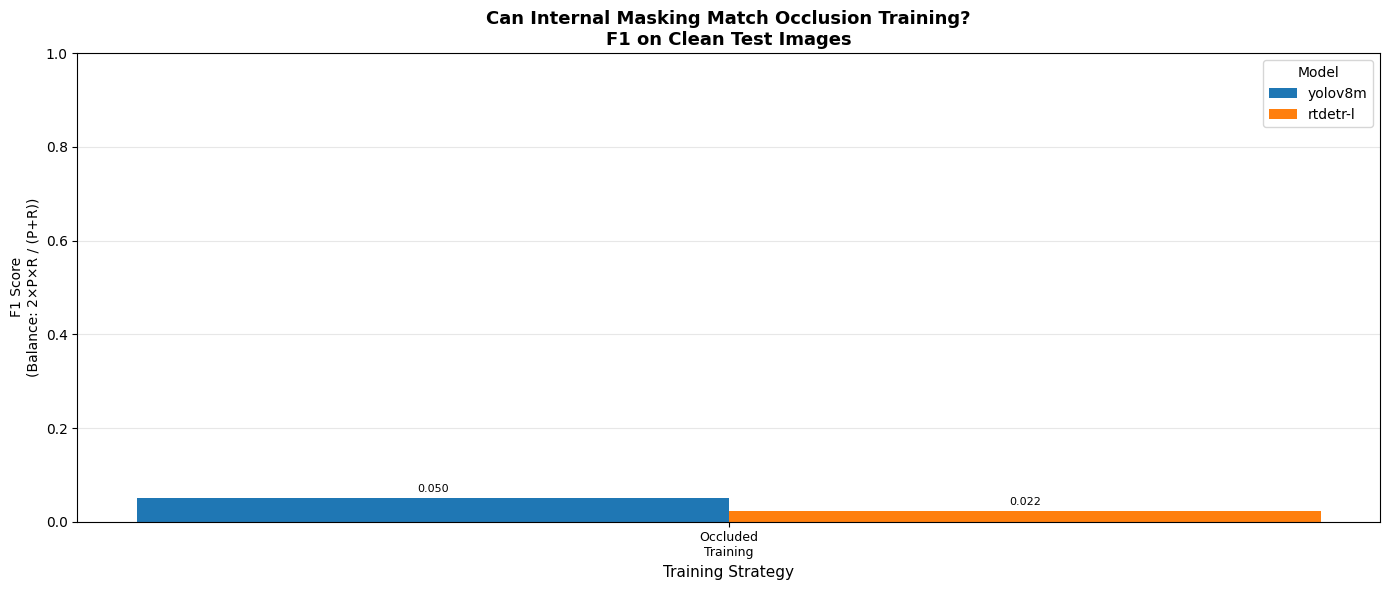

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs/plots/comparison_f1_clean.png


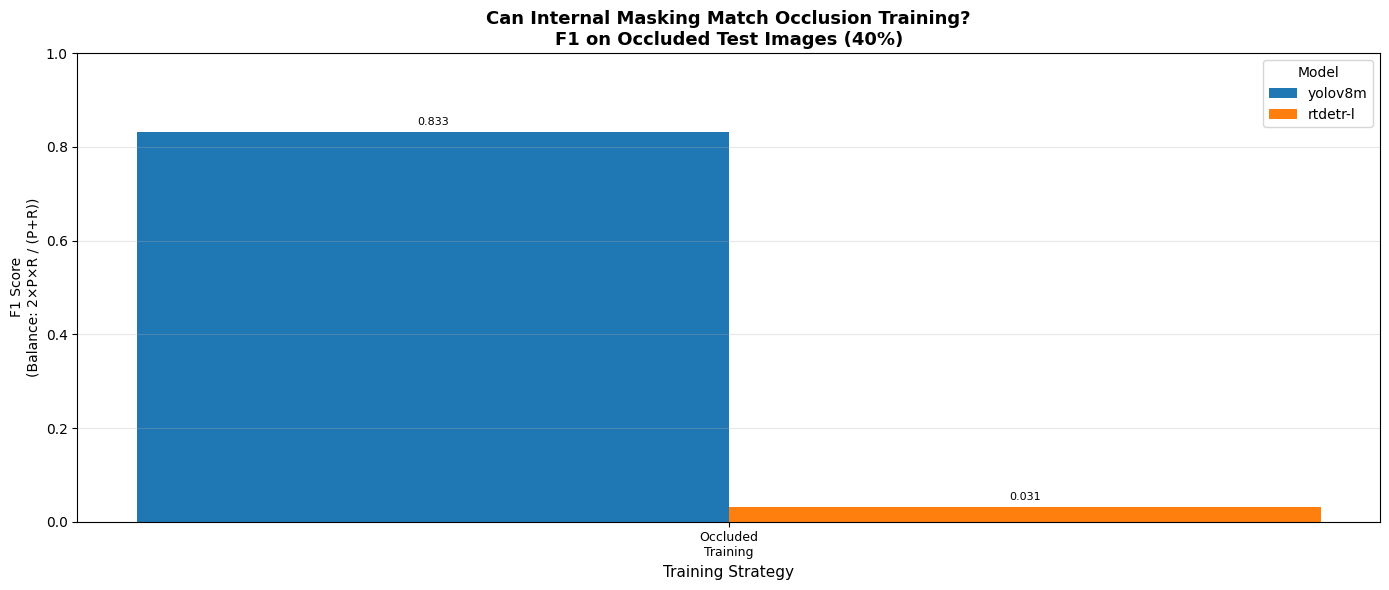

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs/plots/comparison_f1_occluded.png

PRECISION: Of all detections made, how many were correct?


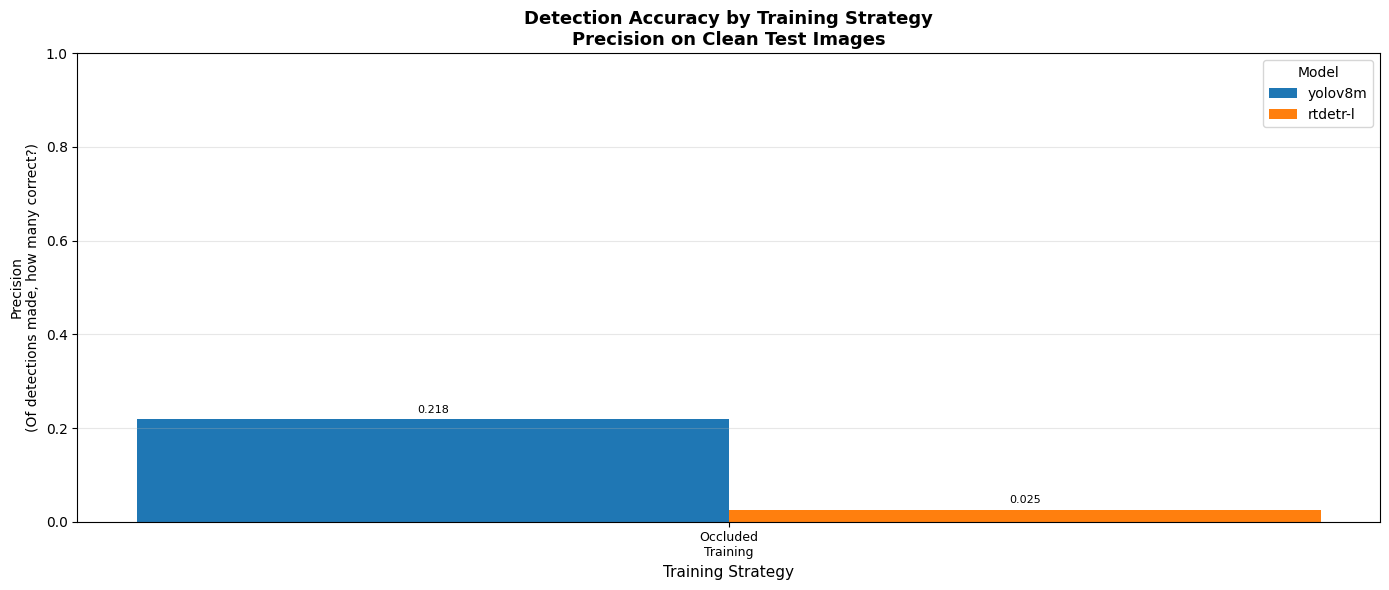

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs/plots/comparison_precision_clean.png


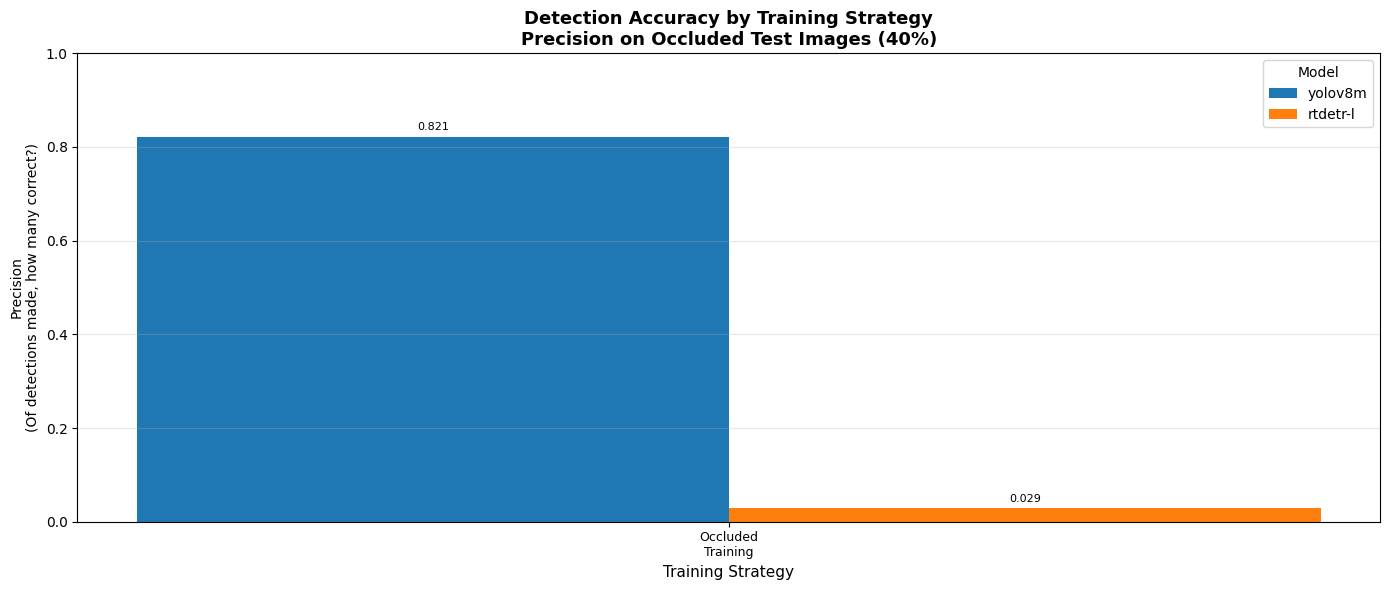

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs/plots/comparison_precision_occluded.png

RECALL: Of all real objects, how many did we find?


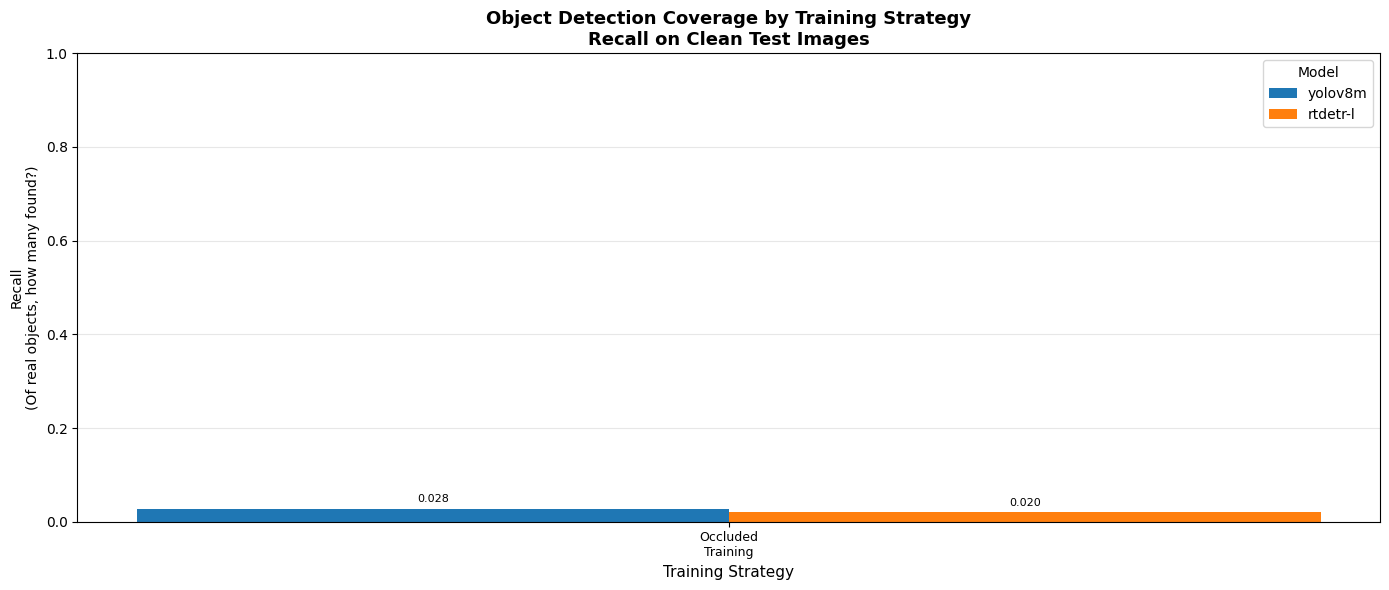

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs/plots/comparison_recall_clean.png


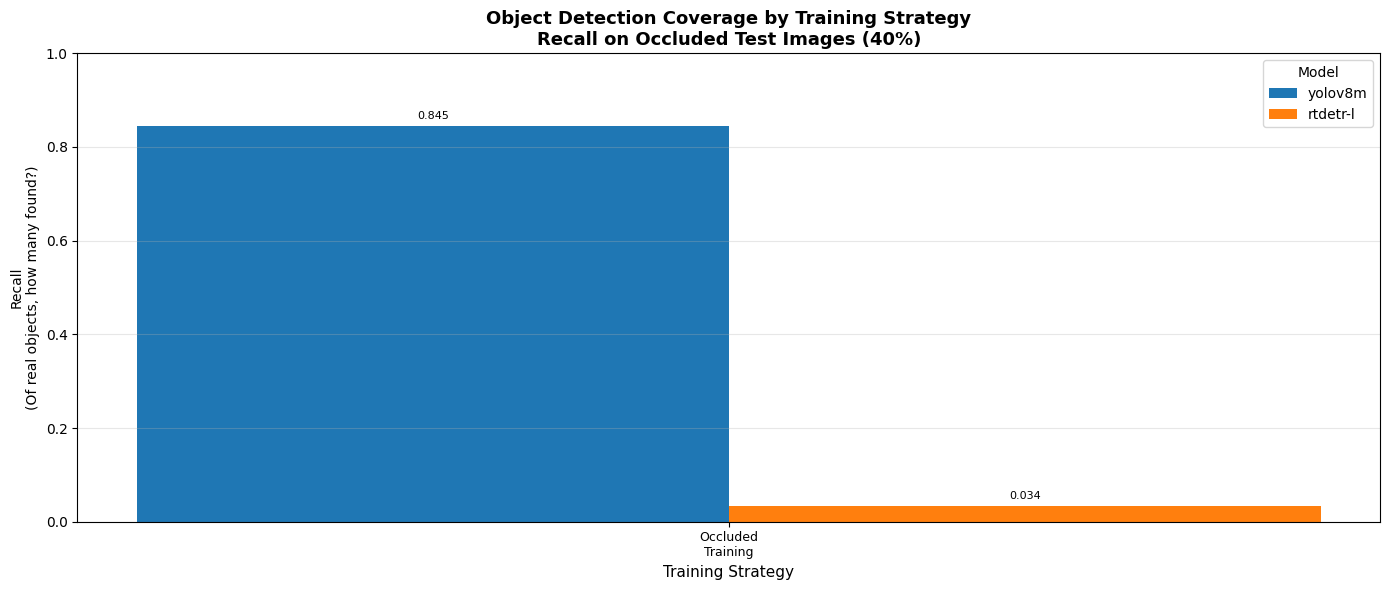

Saved: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs/plots/comparison_recall_occluded.png


In [43]:
# Generate comparison bar plots
import matplotlib.pyplot as plt
import numpy as np

# Enable inline display
%matplotlib inline

if len(df) > 0:
    # Session labels for better readability
    SESSION_LABELS = {
        'S1_clean_train': 'Baseline\n(Clean)',
        'S2_occ_train': 'Occluded\nTraining',
        'S3_mask_backbone_early': 'Mask\nBackbone Early',
        'S4_mask_backbone_late': 'Mask\nBackbone Late',
        'S5_mask_neck': 'Mask\nNeck',
        'S6_mask_head': 'Mask\nHead'
    }

    # Y-axis labels with explanations
    METRIC_LABELS = {
        'f1': 'F1 Score\n(Balance: 2×P×R / (P+R))',
        'precision': 'Precision\n(Of detections made, how many correct?)',
        'recall': 'Recall\n(Of real objects, how many found?)'
    }

    def plot_comparison(df, metric_col, test_type, title, output_path):
        data = df[df['test_type'] == test_type]
        sessions = data['session'].unique()
        models = data['model'].unique()

        x = np.arange(len(sessions))
        width = 0.35

        fig, ax = plt.subplots(figsize=(14, 6))

        for i, model in enumerate(models):
            model_data = data[data['model'] == model]
            values = [model_data[model_data['session'] == s][metric_col].values[0]
                      if len(model_data[model_data['session'] == s]) > 0 else 0
                      for s in sessions]
            offset = width * (i - len(models)/2 + 0.5)
            bars = ax.bar(x + offset, values, width, label=model)

            for bar, val in zip(bars, values):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{val:.3f}', ha='center', va='bottom', fontsize=8)

        ax.set_xlabel('Training Strategy', fontsize=11)
        ax.set_ylabel(METRIC_LABELS.get(metric_col, metric_col.upper()), fontsize=10)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([SESSION_LABELS.get(s, s) for s in sessions], fontsize=9)
        ax.legend(title='Model', fontsize=10)
        ax.set_ylim(0, 1.0)
        ax.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.show()  # Display inline
        print(f"Saved: {output_path}")

    plots_dir = output_dir / "plots"
    plots_dir.mkdir(exist_ok=True)

    # F1 Score plots
    print("\n" + "="*70)
    print("F1 SCORE: Balance between Precision and Recall")
    print("="*70)
    plot_comparison(df, 'f1', 'clean',
        'Can Internal Masking Match Occlusion Training?\nF1 on Clean Test Images',
        plots_dir / "comparison_f1_clean.png")
    plot_comparison(df, 'f1', 'occluded',
        'Can Internal Masking Match Occlusion Training?\nF1 on Occluded Test Images (40%)',
        plots_dir / "comparison_f1_occluded.png")

    # Precision plots
    print("\n" + "="*70)
    print("PRECISION: Of all detections made, how many were correct?")
    print("="*70)
    plot_comparison(df, 'precision', 'clean',
        'Detection Accuracy by Training Strategy\nPrecision on Clean Test Images',
        plots_dir / "comparison_precision_clean.png")
    plot_comparison(df, 'precision', 'occluded',
        'Detection Accuracy by Training Strategy\nPrecision on Occluded Test Images (40%)',
        plots_dir / "comparison_precision_occluded.png")

    # Recall plots
    print("\n" + "="*70)
    print("RECALL: Of all real objects, how many did we find?")
    print("="*70)
    plot_comparison(df, 'recall', 'clean',
        'Object Detection Coverage by Training Strategy\nRecall on Clean Test Images',
        plots_dir / "comparison_recall_clean.png")
    plot_comparison(df, 'recall', 'occluded',
        'Object Detection Coverage by Training Strategy\nRecall on Occluded Test Images (40%)',
        plots_dir / "comparison_recall_occluded.png")
else:
    print("No data to plot")

DETAILED EVALUATION PLOTS

For each evaluation, we generate:
  1. Threshold Sweep - P/R/F1 vs confidence threshold
  2. Per-Class F1 - Which ingredients are detected best?
  3. Confusion Matrix - What gets confused with what?
  4. Count MAE - How accurate is ingredient counting?


  rtdetr-l__S2_occ_train__test_clean

Threshold Sweep (P/R/F1 vs Confidence):


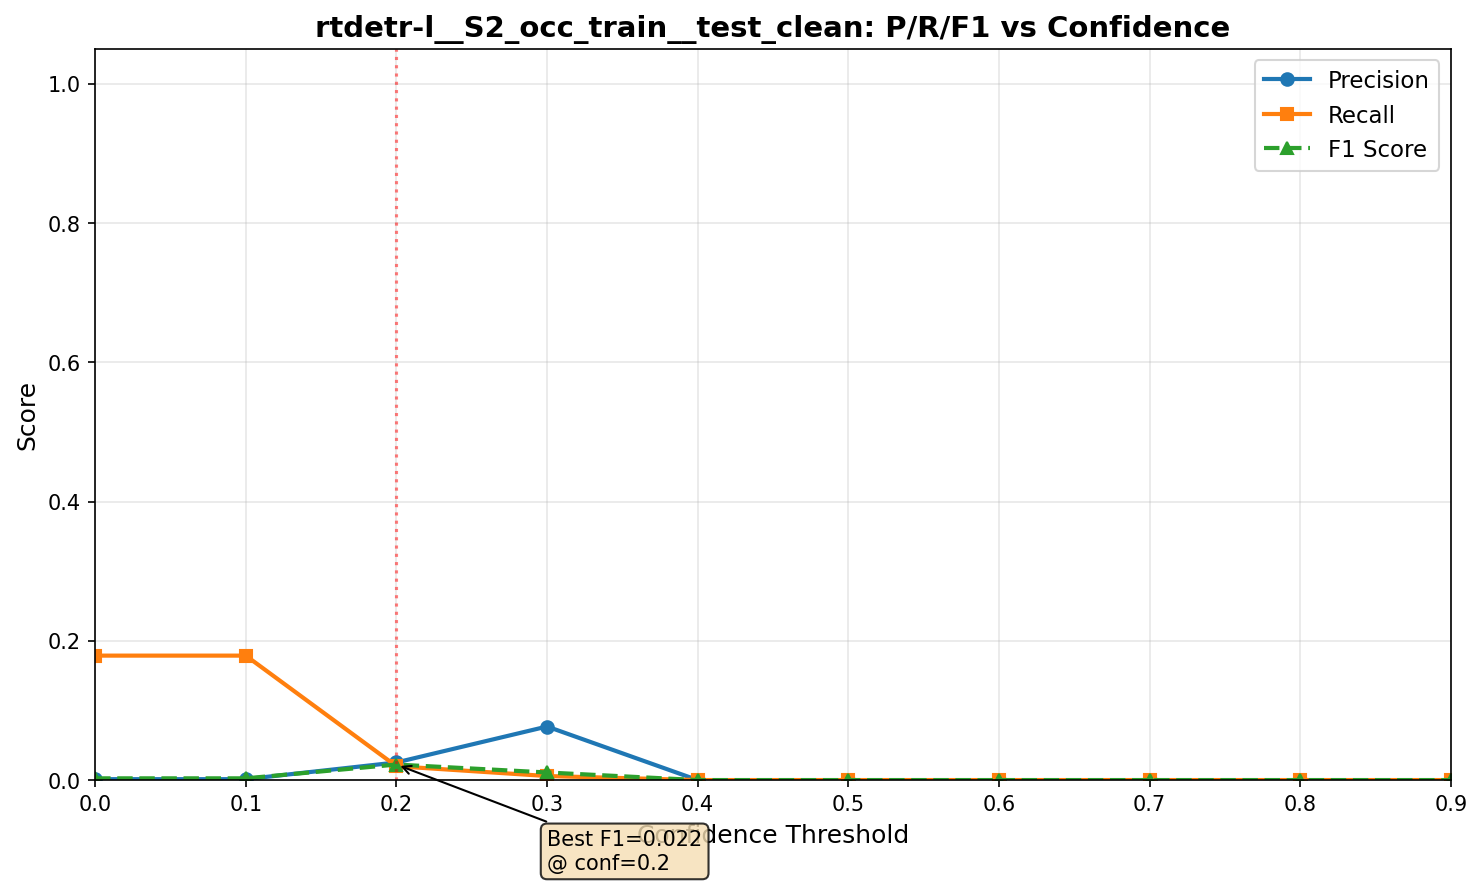


Per-Class F1 Score:


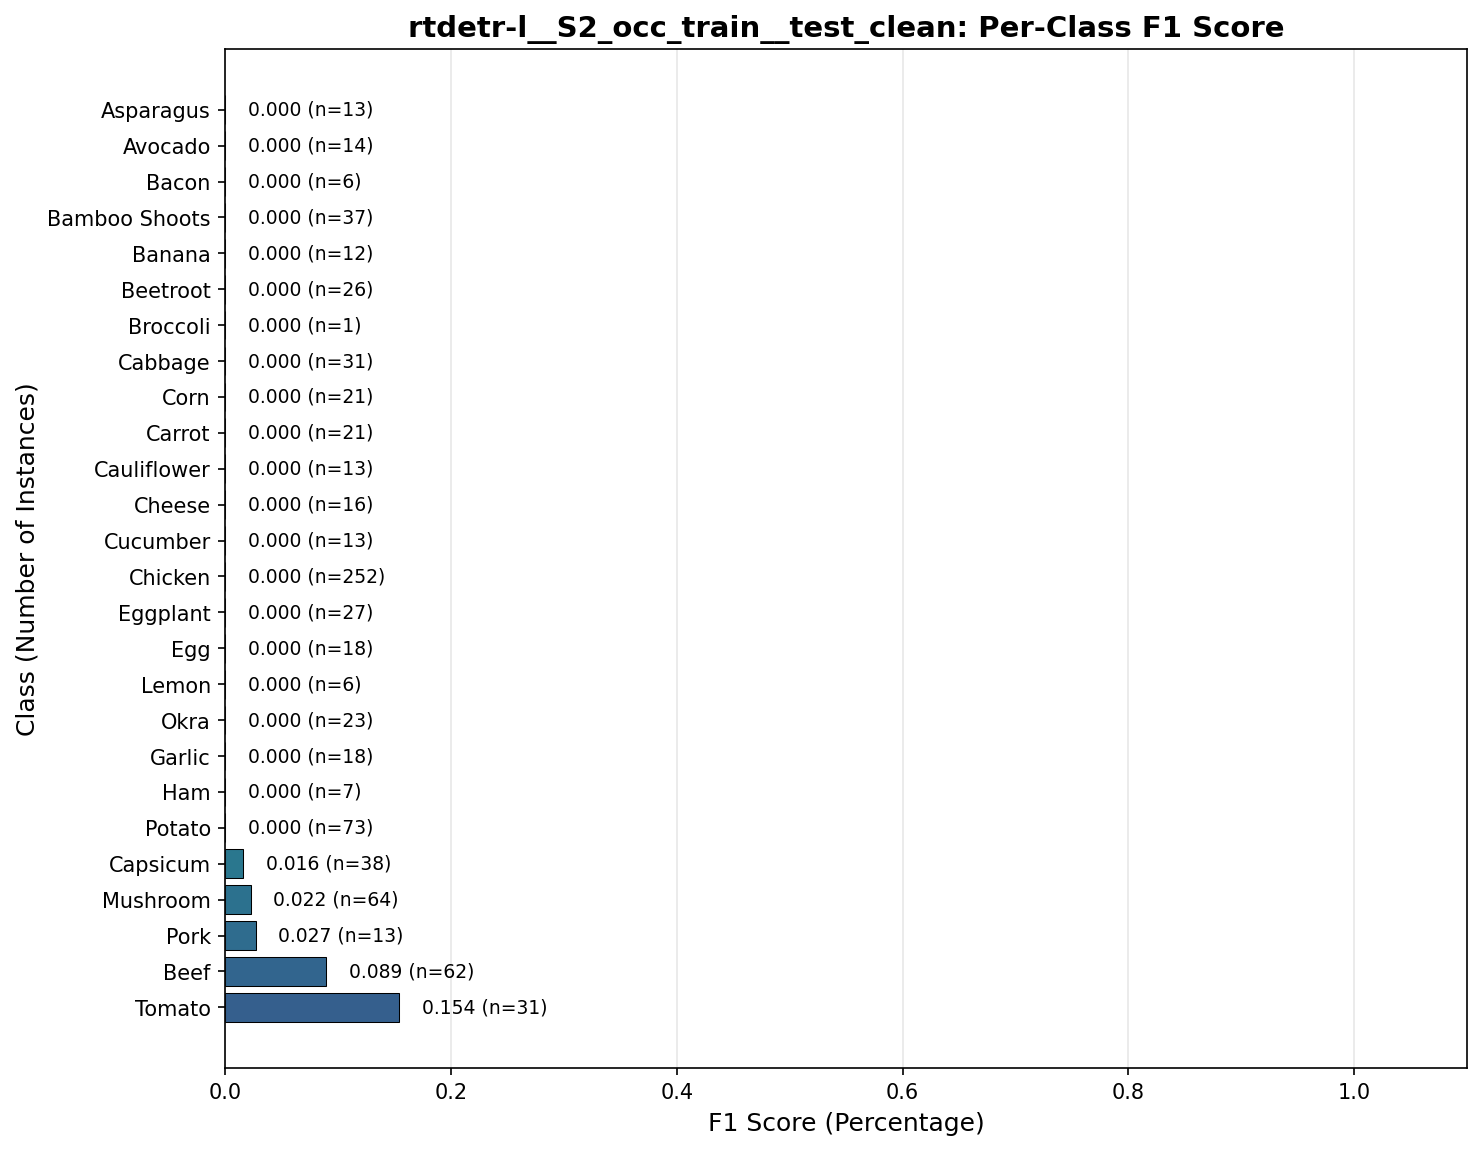


Confusion Matrix:


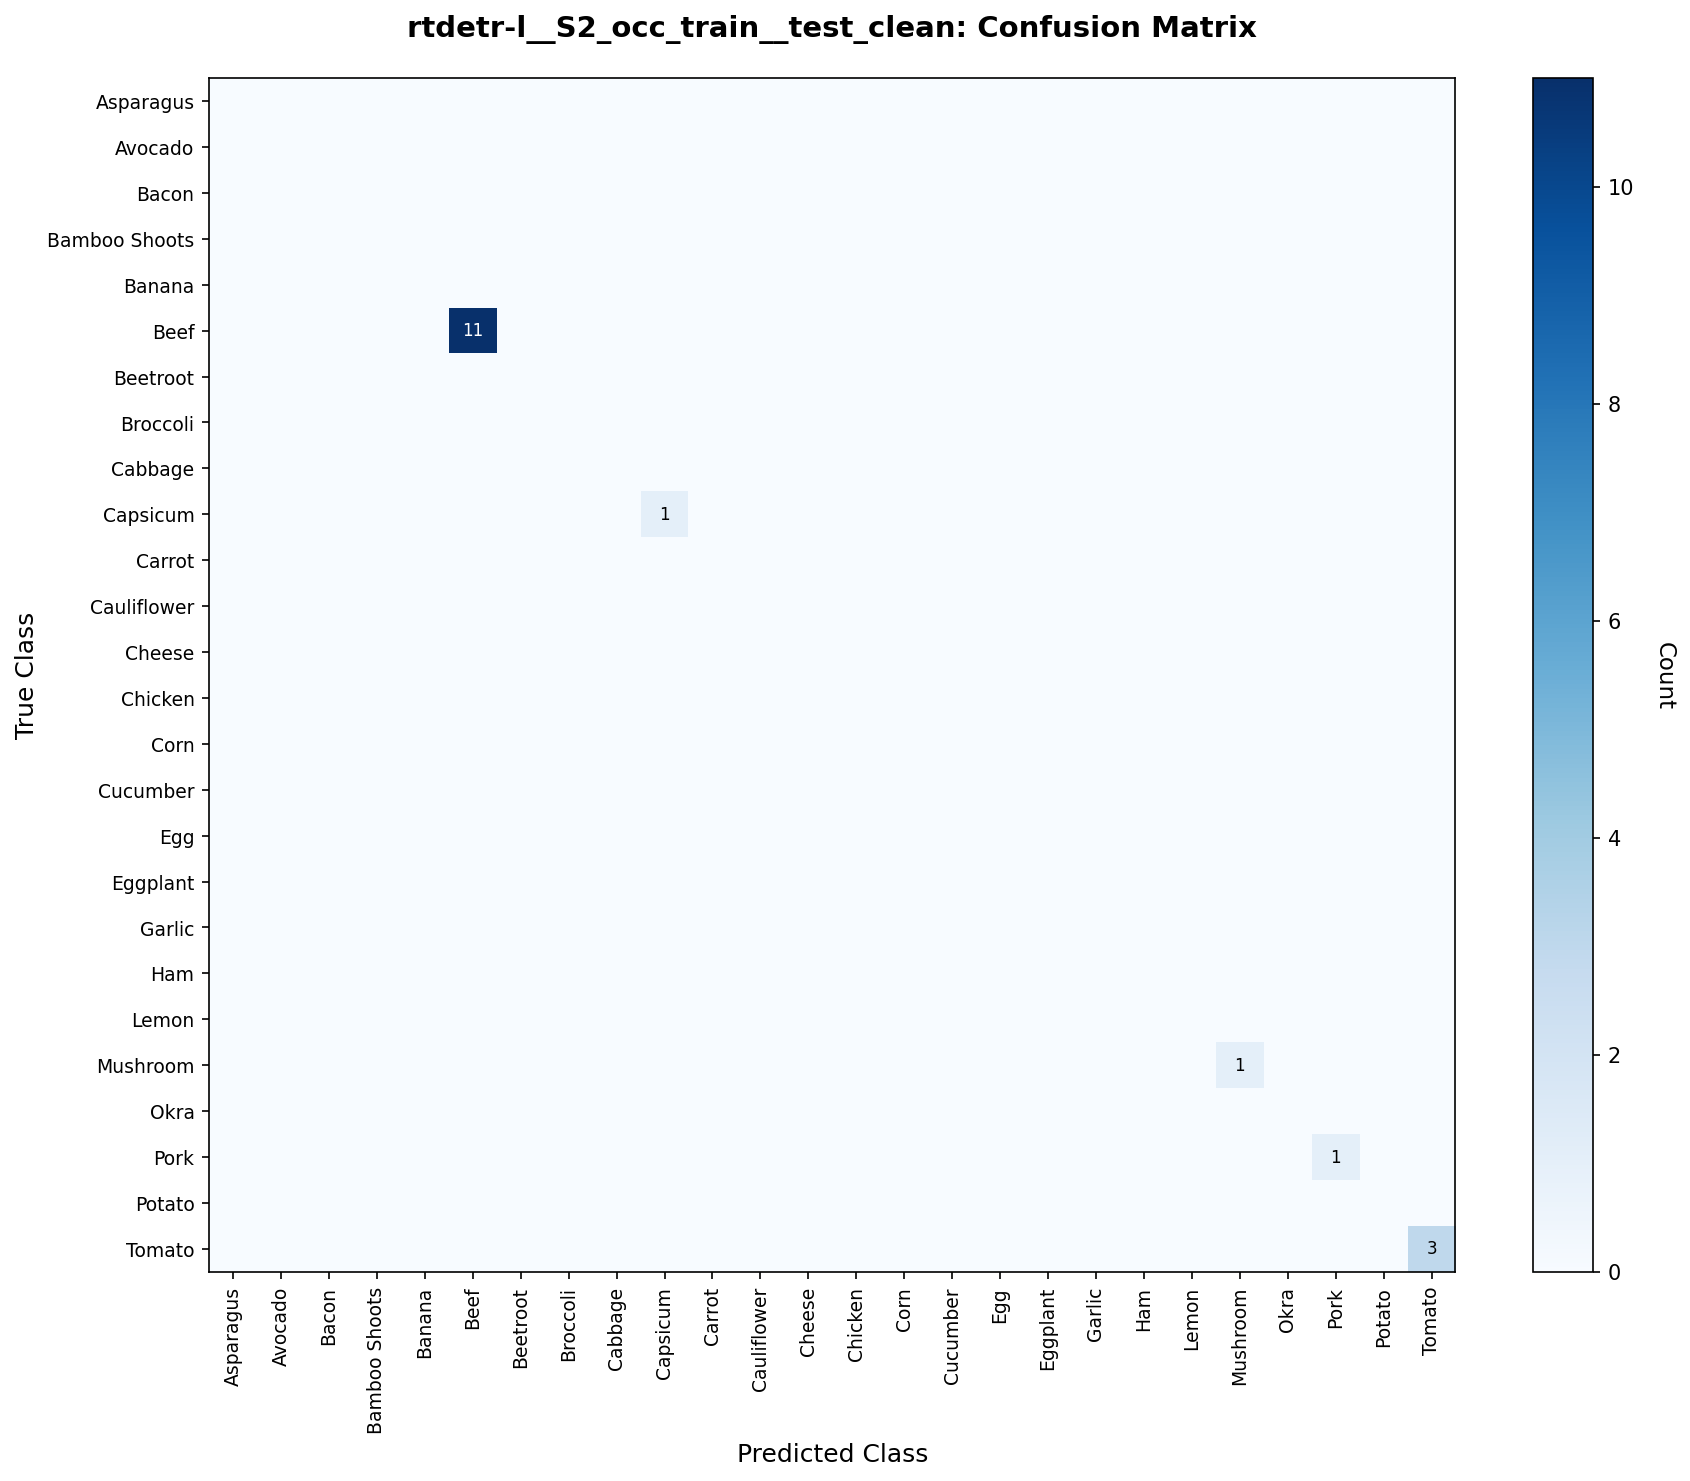


Count MAE Comparison:


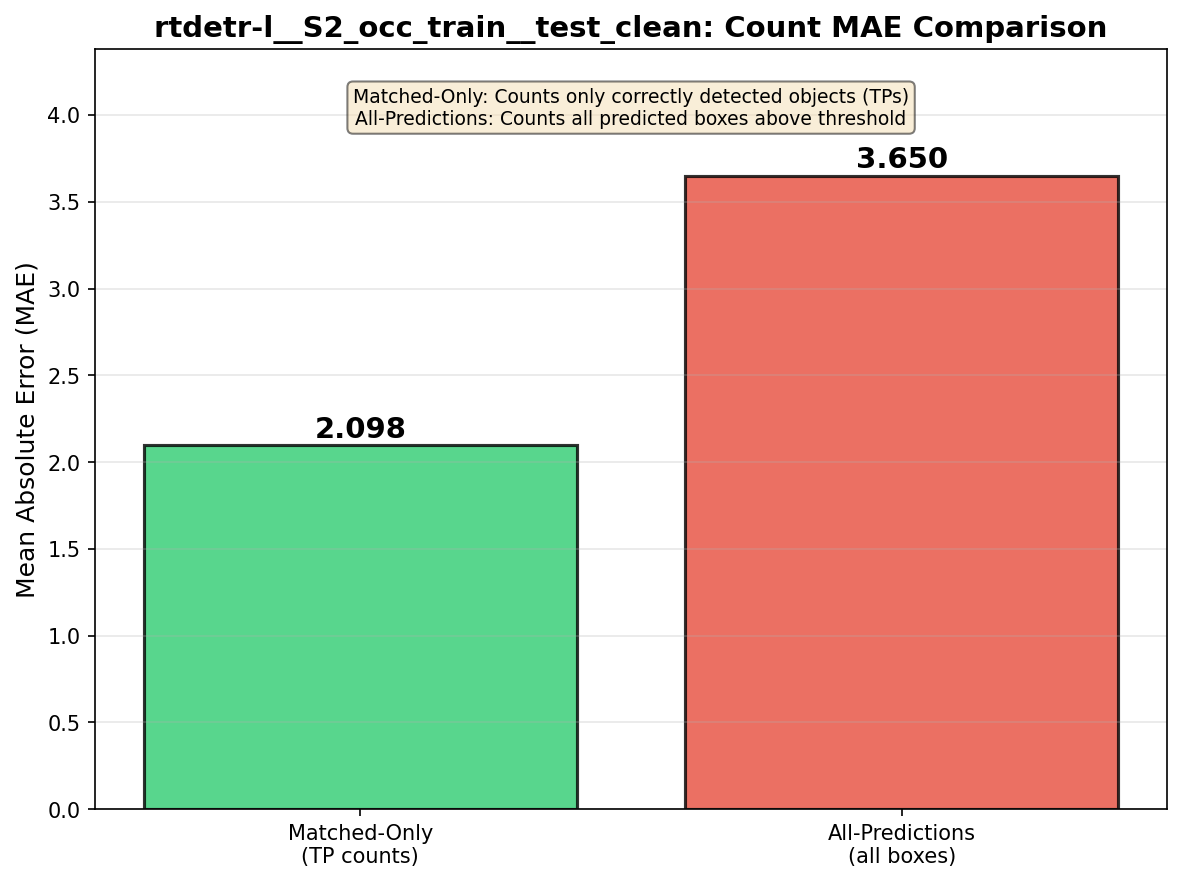


  rtdetr-l__S2_occ_train__test_occluded

Threshold Sweep (P/R/F1 vs Confidence):


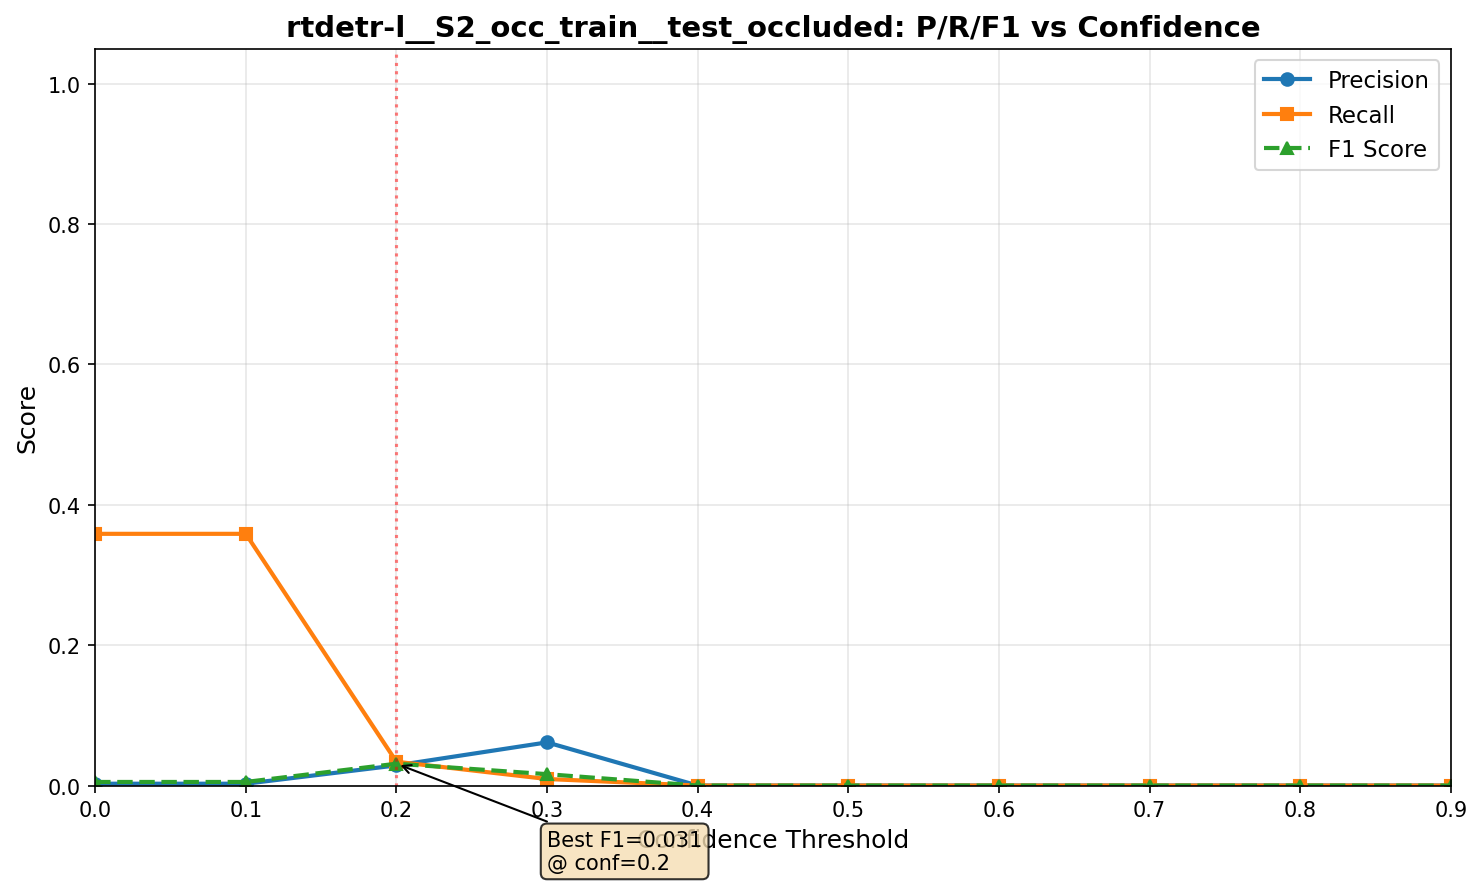


Per-Class F1 Score:


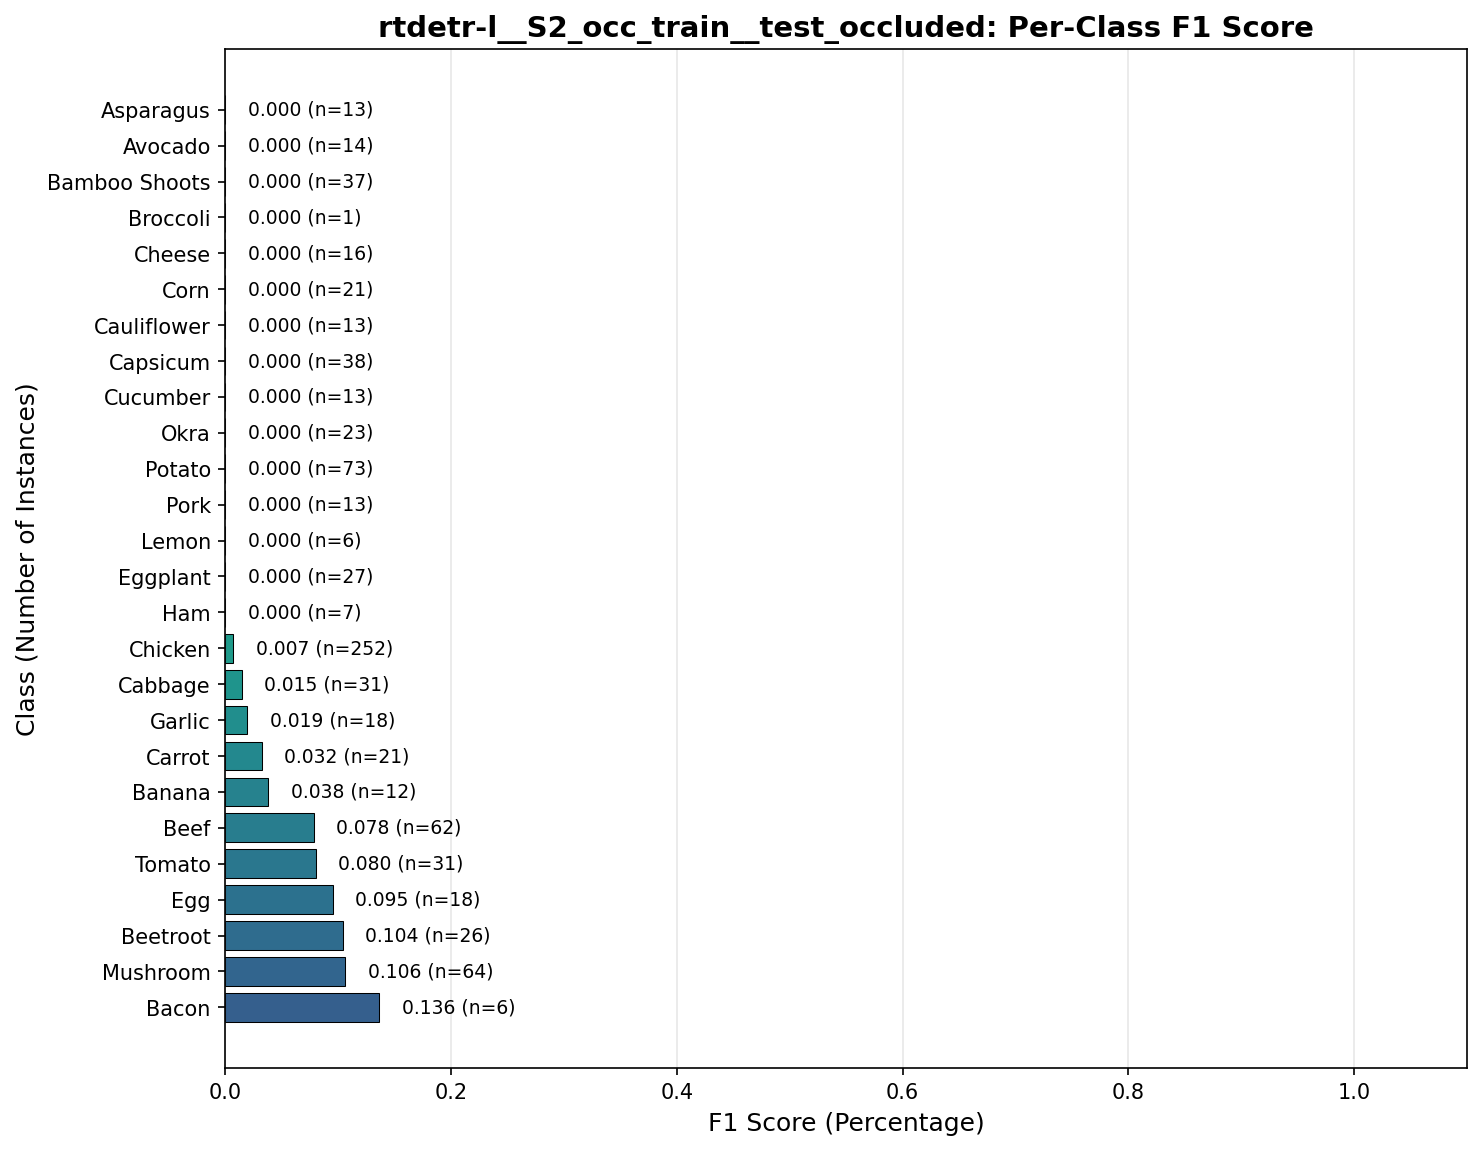


Confusion Matrix:


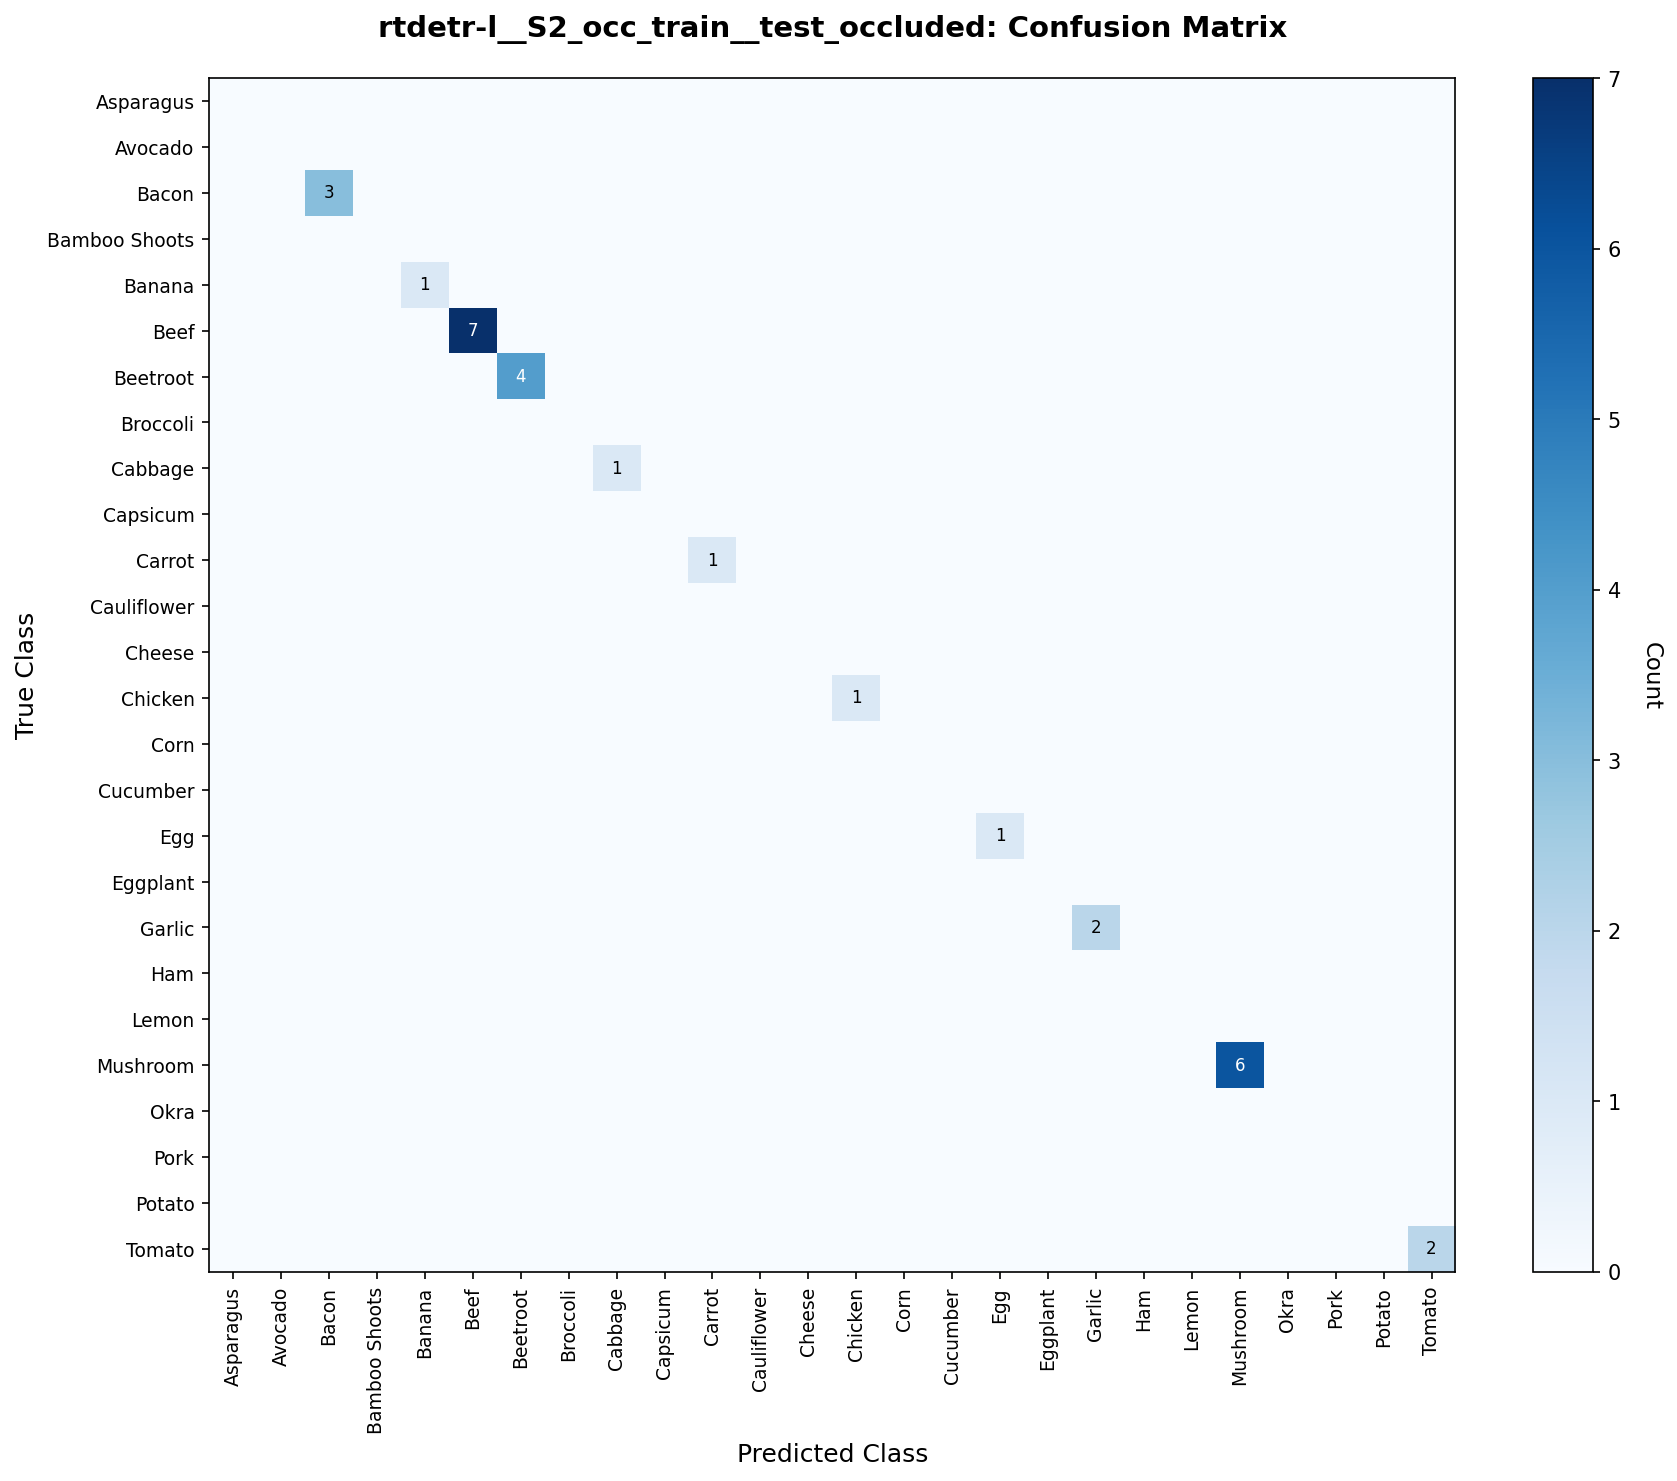


Count MAE Comparison:


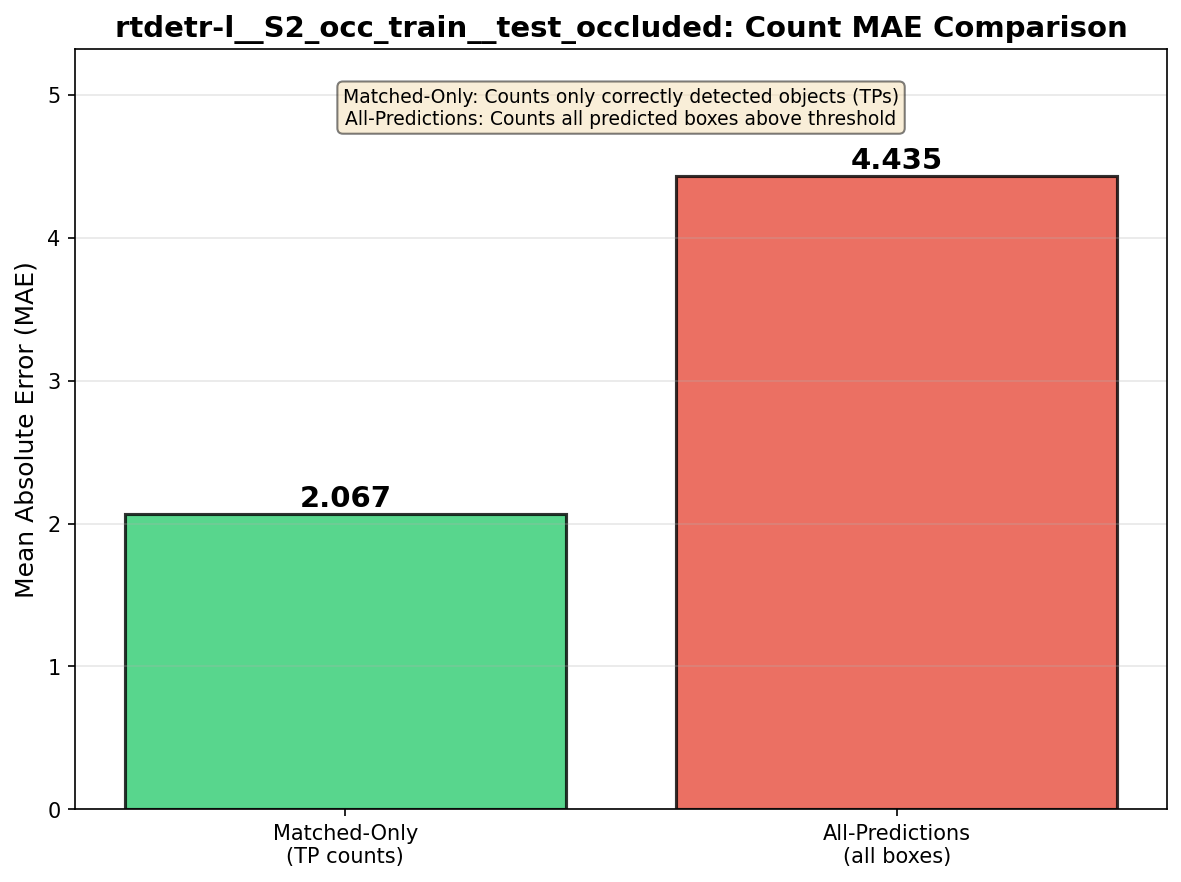


  yolov8m__S2_occ_train__test_clean

Threshold Sweep (P/R/F1 vs Confidence):


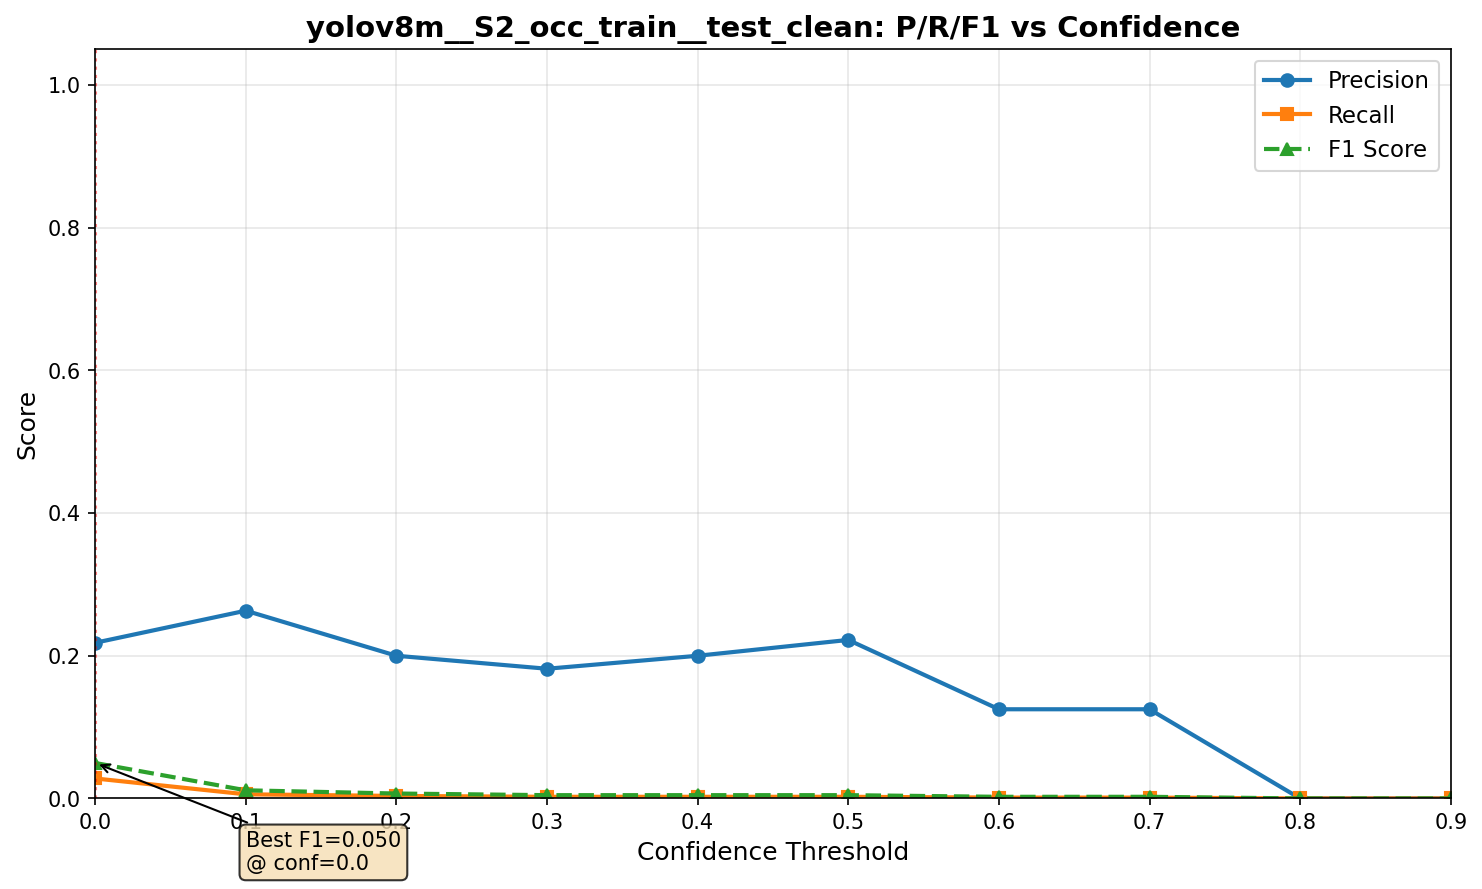


Per-Class F1 Score:


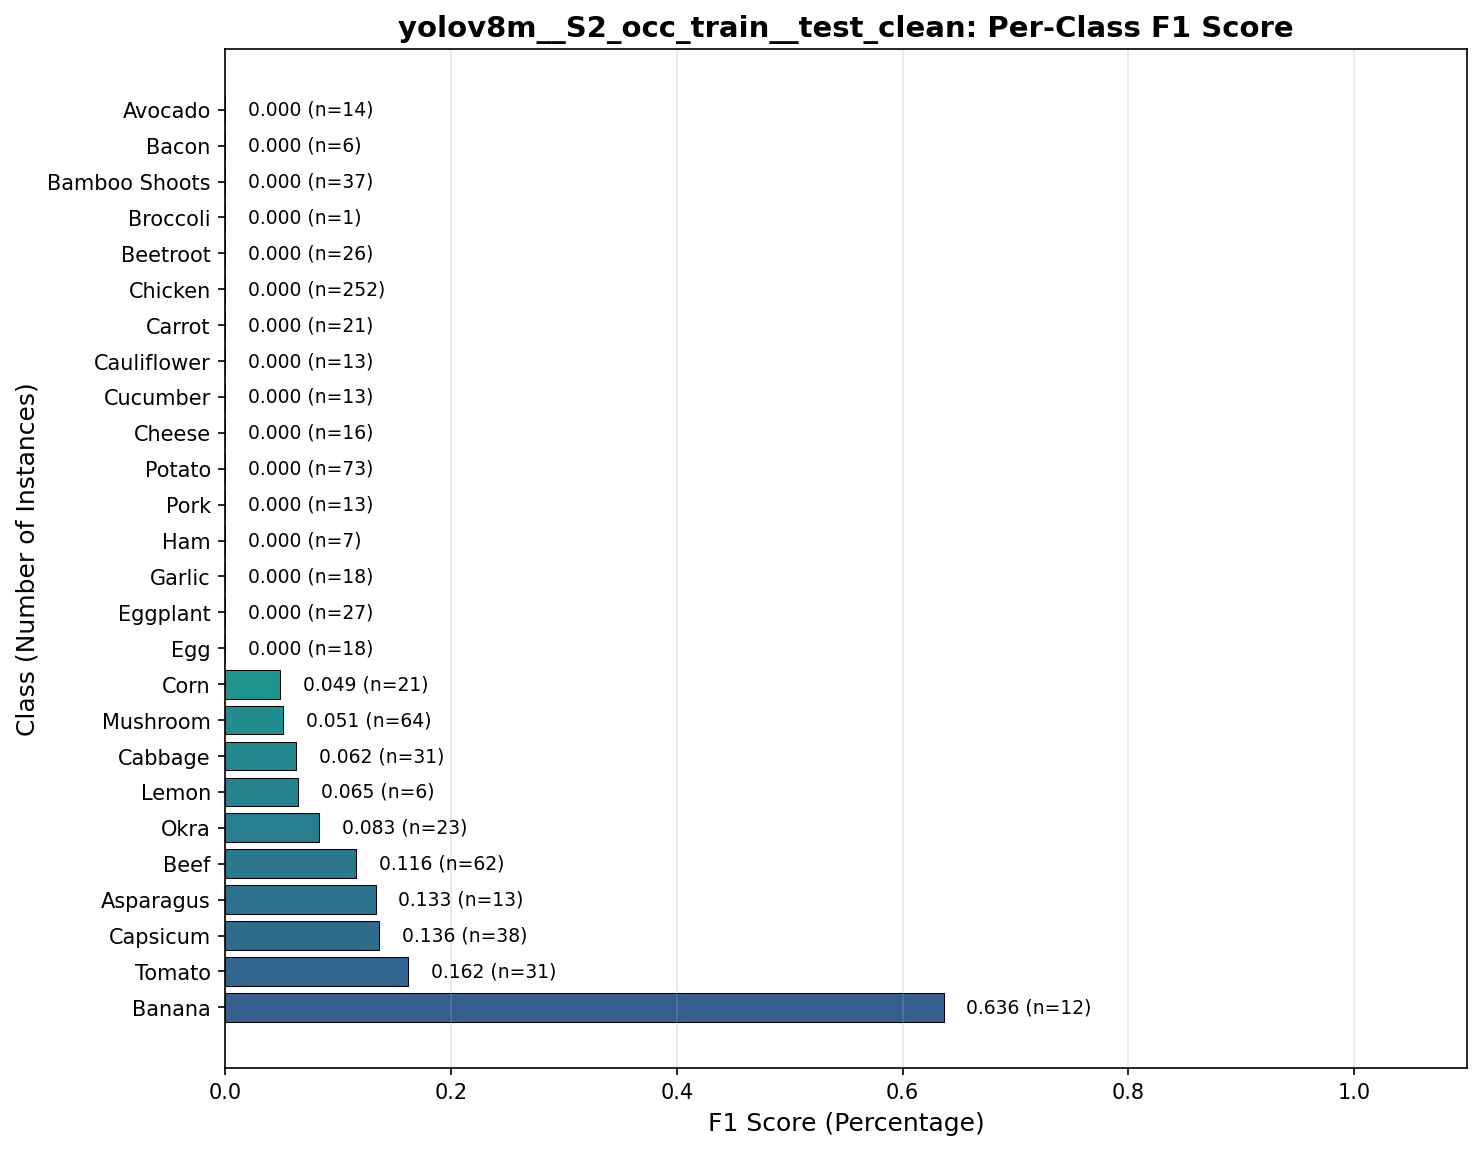


Confusion Matrix:


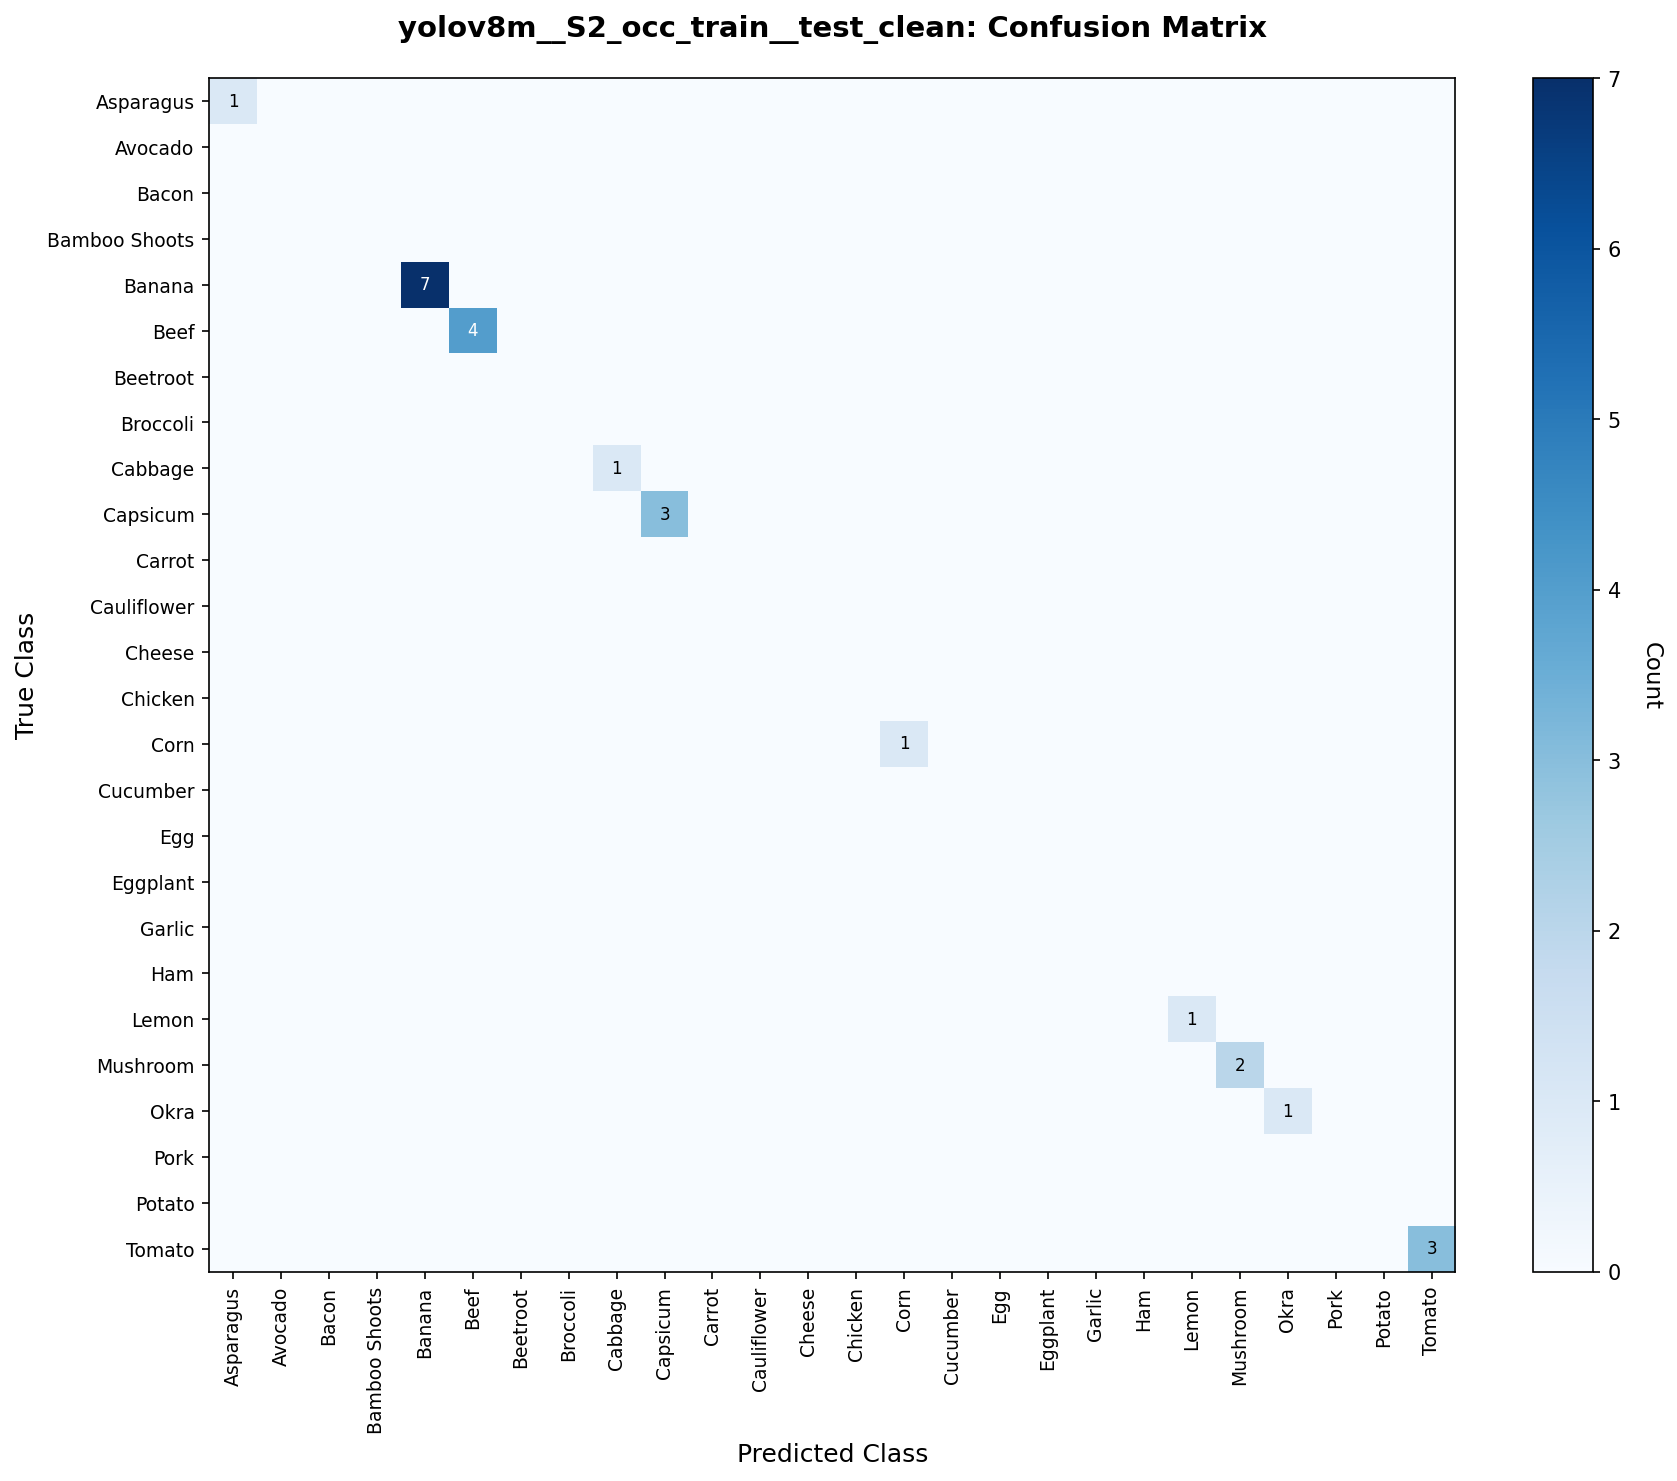


Count MAE Comparison:


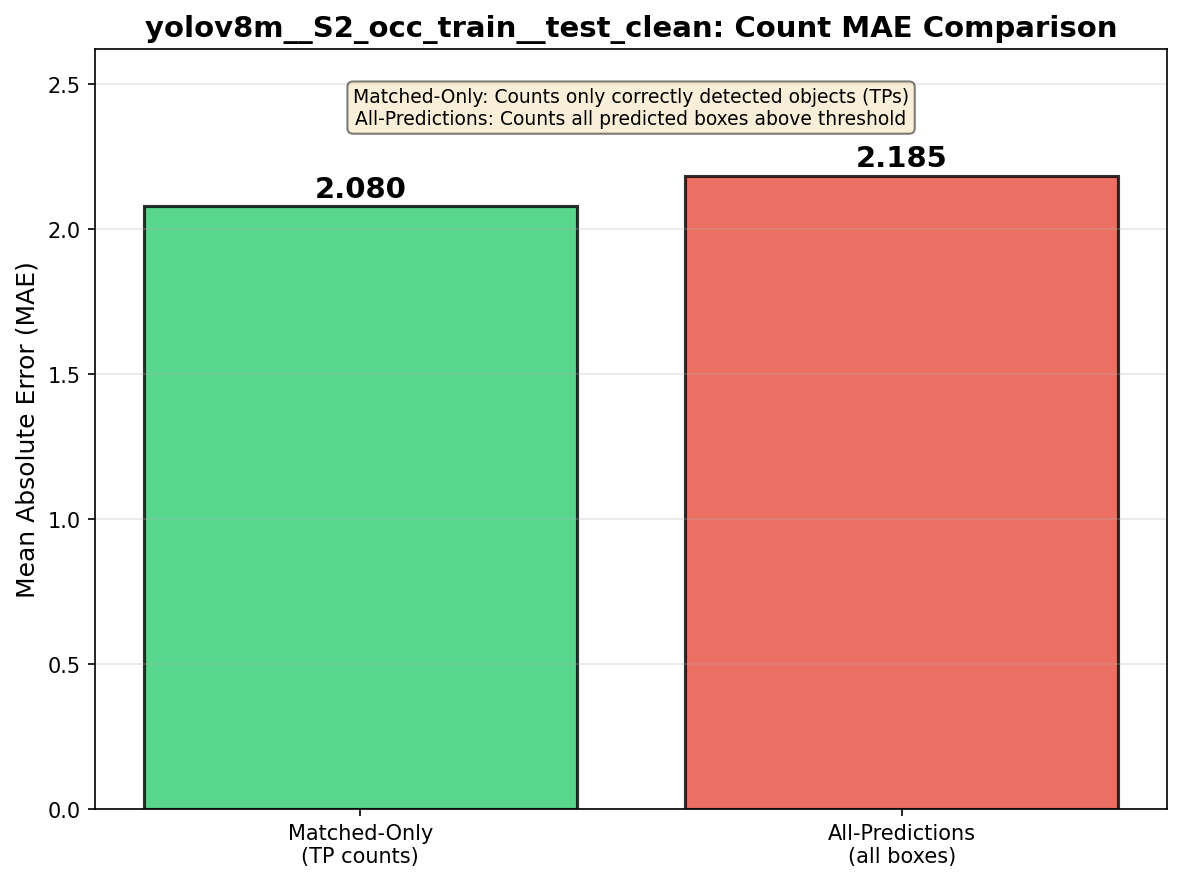


  yolov8m__S2_occ_train__test_occluded

Threshold Sweep (P/R/F1 vs Confidence):


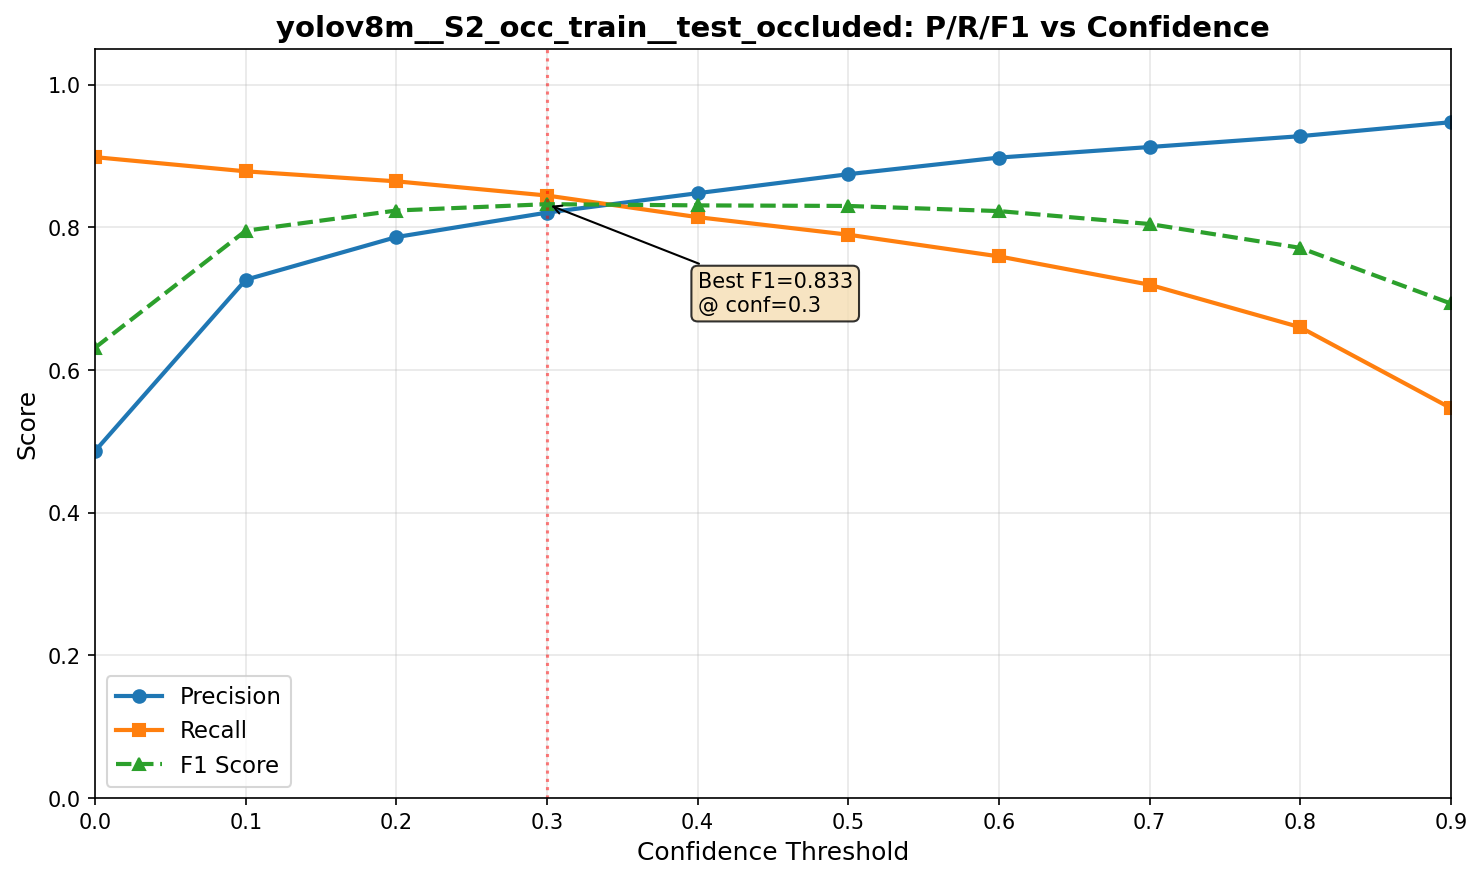


Per-Class F1 Score:


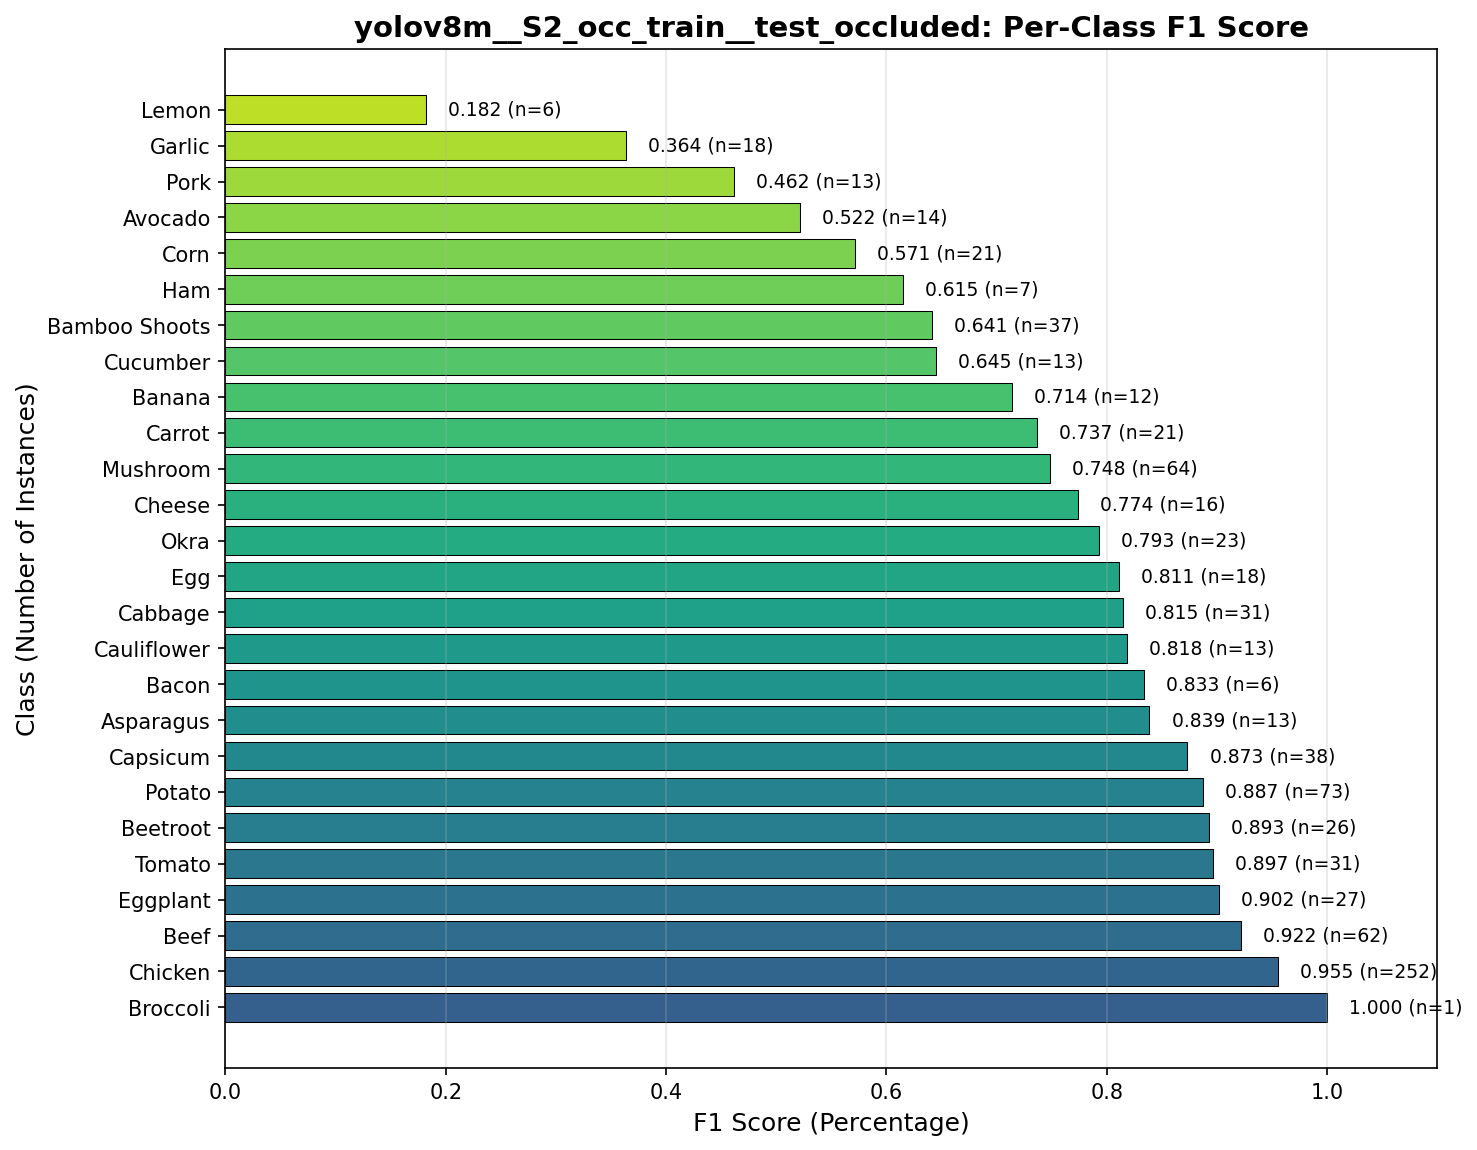


Confusion Matrix:


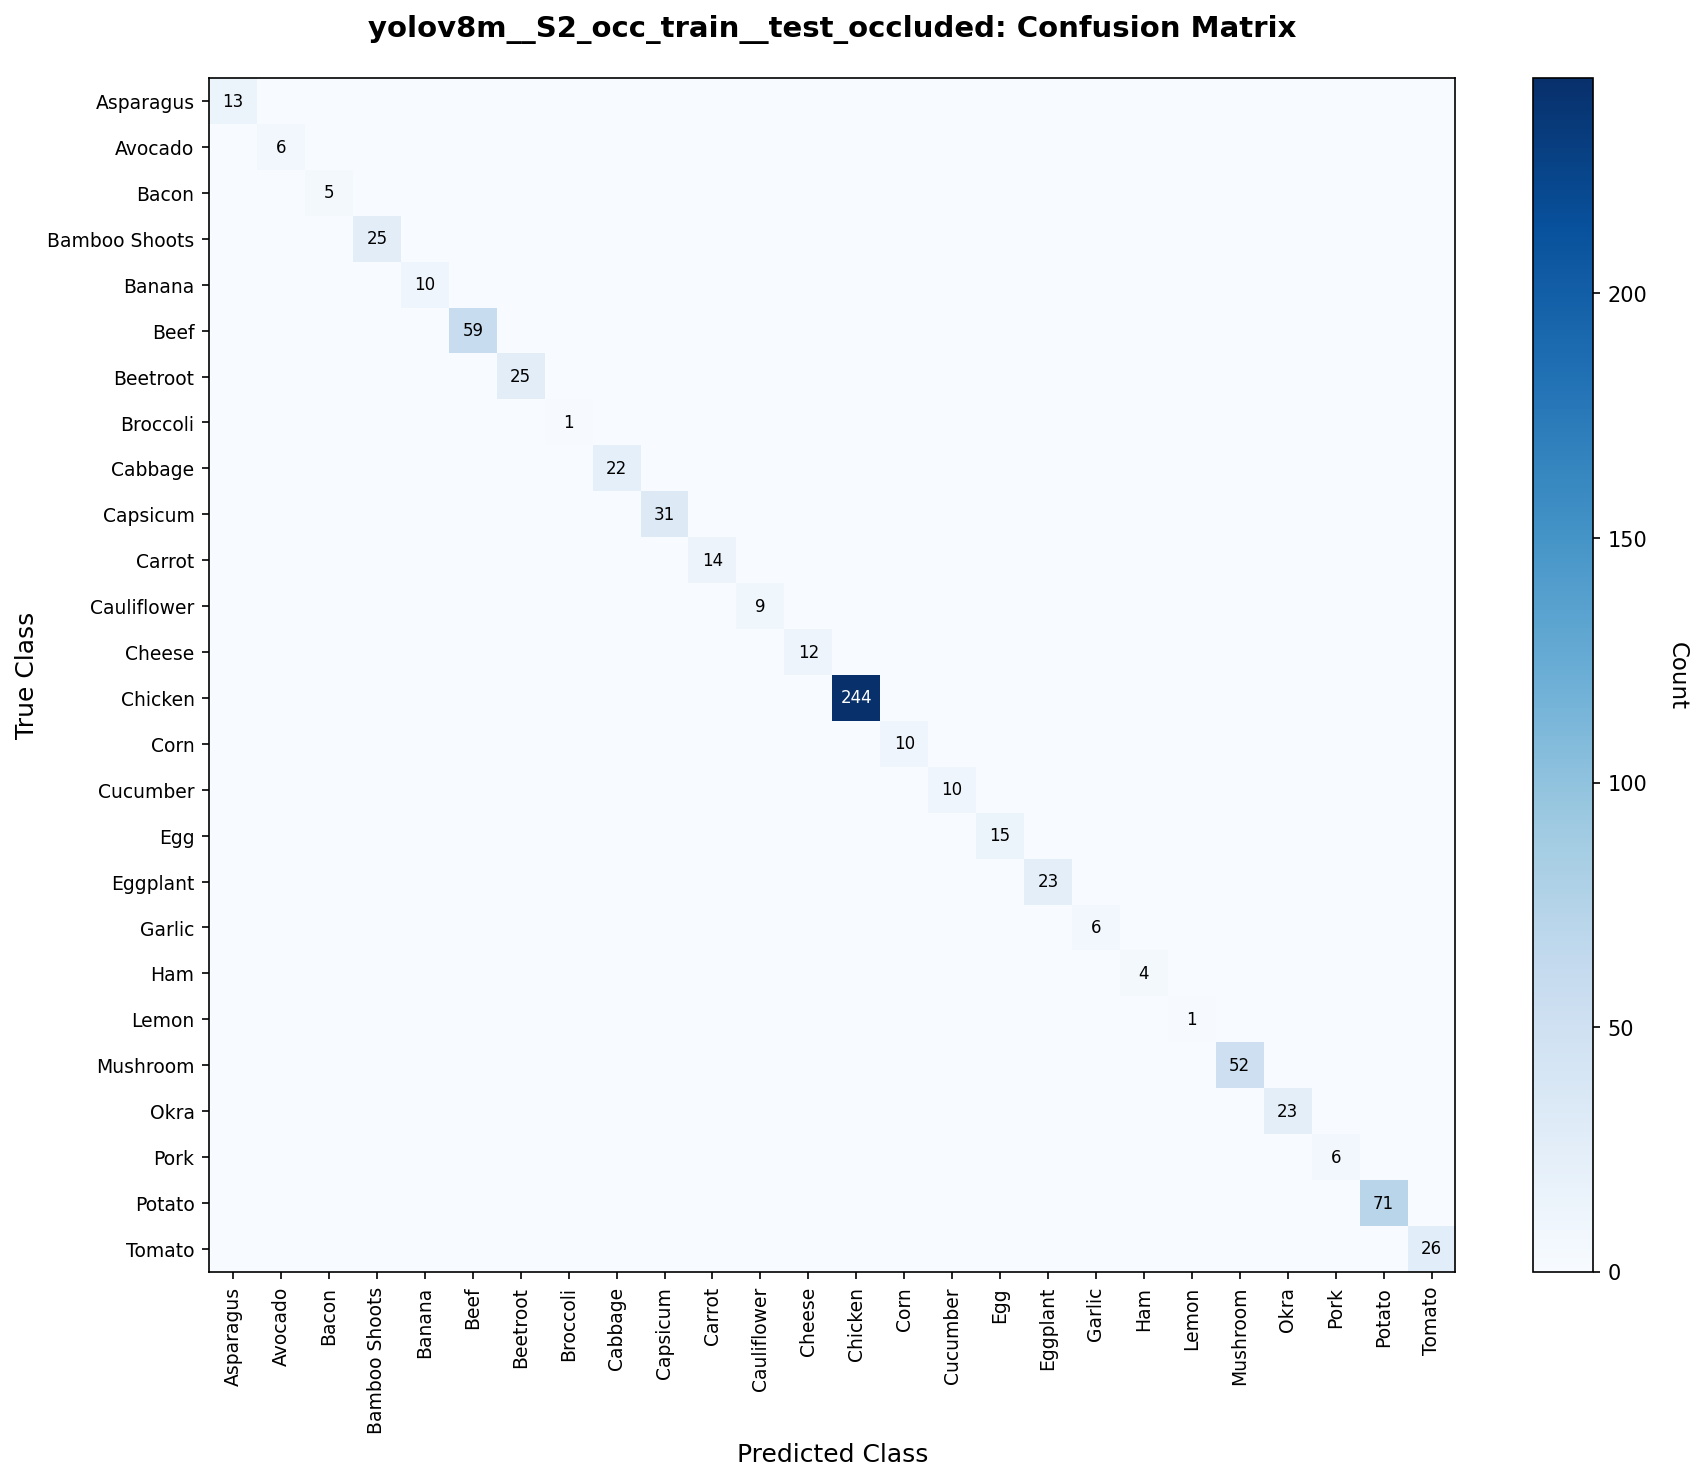


Count MAE Comparison:


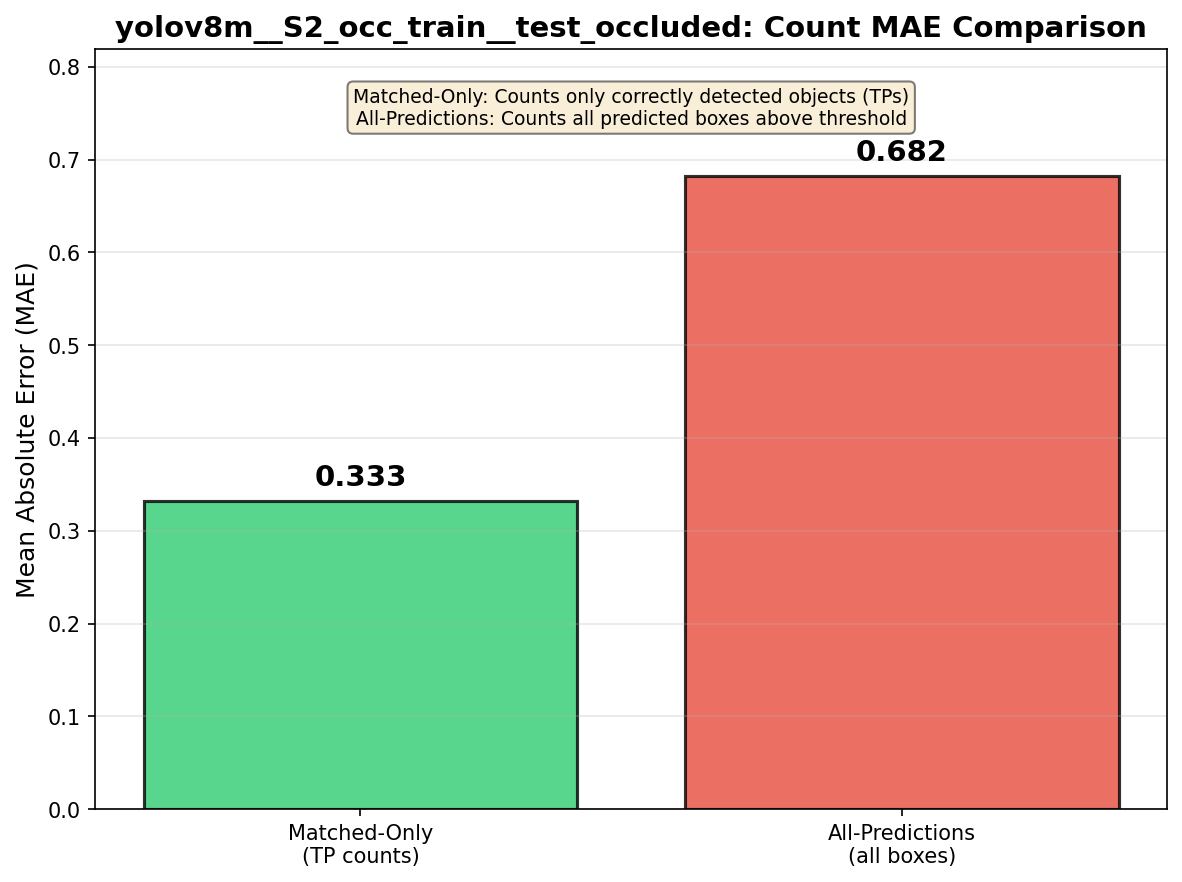

In [44]:
# Display detailed evaluation plots (confusion matrix, threshold sweep, etc.)
# These are generated per model+session+test_type during evaluation

from IPython.display import display, Image as IPImage
import glob

print("="*70)
print("DETAILED EVALUATION PLOTS")
print("="*70)
print("\nFor each evaluation, we generate:")
print("  1. Threshold Sweep - P/R/F1 vs confidence threshold")
print("  2. Per-Class F1 - Which ingredients are detected best?")
print("  3. Confusion Matrix - What gets confused with what?")
print("  4. Count MAE - How accurate is ingredient counting?")
print()

# Find all evaluation directories
eval_dirs = sorted(glob.glob(str(output_dir / "evaluations" / "*")))

for eval_dir in eval_dirs:
    eval_name = Path(eval_dir).name
    print(f"\n{'='*70}")
    print(f"  {eval_name}")
    print(f"{'='*70}")

    # Display each plot type
    plot_files = [
        ("Threshold Sweep (P/R/F1 vs Confidence)", "threshold_sweep.png"),
        ("Per-Class F1 Score", "per_class_f1.png"),
        ("Confusion Matrix", "confusion_matrix.png"),
        ("Count MAE Comparison", "count_mae_comparison.png")
    ]

    for plot_title, plot_filename in plot_files:
        plot_path = Path(eval_dir) / plot_filename
        if plot_path.exists():
            print(f"\n{plot_title}:")
            display(IPImage(filename=str(plot_path), width=800))
        else:
            print(f"\n{plot_title}: Not found")

## 9.1 Evaluate Train/Val Splits (Overfitting Analysis)

This section evaluates all 12 trained models on the **train** and **val** splits to check for overfitting.
- If F1_train >> F1_val >> F1_test → overfitting
- If F1_train ≈ F1_val ≈ F1_test (But all low, < 0.3) → underfitting
- If F1_train ≈ F1_val ≈ F1_test (But not all low < 0.3) → good generalization

In [45]:
# Evaluate all models on train and val splits (clean images only)
# This helps detect overfitting: if F1_train >> F1_val >> F1_test, the model overfits

print("="*70)
print("EVALUATING TRAIN/VAL SPLITS FOR OVERFITTING ANALYSIS")
print("="*70)
print(f"This will run inference on {len(MODELS) * len(SESSIONS_TO_RUN)} models x 2 splits = {len(MODELS) * len(SESSIONS_TO_RUN) * 2} evaluations")
print("Estimated time: ~10-15 minutes\n")

# Load indices
with open("data/processed/evaluation/train_index.json") as f:
    train_index = json.load(f)
with open("data/processed/evaluation/val_index.json") as f:
    val_index = json.load(f)

# Load ground truth and class names
train_gts = load_ground_truth("data/processed/evaluation/train_index.json")
val_gts = load_ground_truth("data/processed/evaluation/val_index.json")
class_names = load_class_names("data/processed/evaluation/test_index.json")

# Store results
train_val_metrics = []

for model_name in MODELS:
    for session_name in SESSIONS_TO_RUN:
        # Check if training completed
        if not is_session_complete(output_dir, model_name, session_name):
            print(f"SKIP (no training): {model_name}__{session_name}")
            continue

        # Find weights
        run_dir = output_dir / f"{model_name}__{session_name}"
        weights_path = run_dir / "weights" / "best.pt"

        if not weights_path.exists():
            print(f"WARNING: Weights not found for {model_name}__{session_name}")
            continue

        print(f"\n[{model_name}__{session_name}]")

        # Evaluate on TRAIN split (clean images)
        print(f"  Evaluating on train split ({len(train_index['images'])} images)...")
        train_preds = generate_predictions(str(weights_path), "data/raw/train/images", train_index)
        train_sweep = eval_detection_prf_at_iou(train_preds, train_gts, iou_threshold=0.5)
        train_best_thr = max(train_sweep.keys(), key=lambda k: train_sweep[k]['f1'])
        train_metrics = train_sweep[train_best_thr]
        print(f"    Train F1: {train_metrics['f1']:.4f} @ conf={train_best_thr}")

        # Evaluate on VAL split (clean images)
        print(f"  Evaluating on val split ({len(val_index['images'])} images)...")
        val_preds = generate_predictions(str(weights_path), "data/raw/valid/images", val_index)
        val_sweep = eval_detection_prf_at_iou(val_preds, val_gts, iou_threshold=0.5)
        val_best_thr = max(val_sweep.keys(), key=lambda k: val_sweep[k]['f1'])
        val_metrics = val_sweep[val_best_thr]
        print(f"    Val F1: {val_metrics['f1']:.4f} @ conf={val_best_thr}")

        # Store results
        train_val_metrics.append({
            "model": model_name,
            "session": session_name,
            "F1_train": train_metrics['f1'],
            "P_train": train_metrics['precision'],
            "R_train": train_metrics['recall'],
            "F1_val": val_metrics['f1'],
            "P_val": val_metrics['precision'],
            "R_val": val_metrics['recall'],
        })

# Save train/val metrics
with open(output_dir / "train_val_metrics.json", 'w') as f:
    json.dump(train_val_metrics, f, indent=2)

print("\n" + "="*70)
print("Train/Val evaluation complete!")
print(f"Saved to: {output_dir / 'train_val_metrics.json'}")
print("="*70)

EVALUATING TRAIN/VAL SPLITS FOR OVERFITTING ANALYSIS
This will run inference on 2 models x 2 splits = 4 evaluations
Estimated time: ~10-15 minutes


[yolov8m__S2_occ_train]
  Evaluating on train split (1384 images)...


Inference: 100%|██████████| 1384/1384 [00:20<00:00, 66.60it/s]


    Train F1: 0.0545 @ conf=0.0
  Evaluating on val split (200 images)...


Inference: 100%|██████████| 200/200 [00:03<00:00, 66.49it/s]


    Val F1: 0.0539 @ conf=0.0

[rtdetr-l__S2_occ_train]
  Evaluating on train split (1384 images)...


Inference: 100%|██████████| 1384/1384 [01:35<00:00, 14.43it/s]


    Train F1: 0.0200 @ conf=0.2
  Evaluating on val split (200 images)...


Inference: 100%|██████████| 200/200 [00:13<00:00, 14.55it/s]


    Val F1: 0.0302 @ conf=0.2

Train/Val evaluation complete!
Saved to: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs/train_val_metrics.json


## 9.2 Comprehensive Results Table (Train/Val/Test)

This table combines train, val, and test metrics to show the full picture:
- **F1_train, P_train, R_train**: Performance on training data (clean)
- **F1_val, P_val, R_val**: Performance on validation data (clean)
- **F1_test_clean, P_test_clean, R_test_clean**: Performance on test data (clean)
- **F1_test_occ, P_test_occ, R_test_occ**: Performance on test data (40% occluded)

**Interpretation:**
- If train >> val >> test_clean: Overfitting
- If train ≈ val ≈ test_clean (But all low): Underfitting
- If train ≈ val ≈ test_clean: Good generalization
- test_clean vs test_occ gap: Occlusion robustness

In [46]:
# Create comprehensive table combining train/val/test metrics
# Merge train_val_metrics with existing test metrics

# Convert train_val_metrics to DataFrame
df_train_val = pd.DataFrame(train_val_metrics)

# Get test metrics from all_metrics (already loaded)
df_test = pd.DataFrame(all_metrics)

# Pivot test metrics to get clean and occluded columns
df_test_clean = df_test[df_test['test_type'] == 'clean'][['model', 'session', 'f1', 'precision', 'recall']].copy()
df_test_clean = df_test_clean.rename(columns={
    'f1': 'F1_test_clean',
    'precision': 'P_test_clean',
    'recall': 'R_test_clean'
})

df_test_occ = df_test[df_test['test_type'] == 'occluded'][['model', 'session', 'f1', 'precision', 'recall']].copy()
df_test_occ = df_test_occ.rename(columns={
    'f1': 'F1_test_occ',
    'precision': 'P_test_occ',
    'recall': 'R_test_occ'
})

# Merge all together
comprehensive = df_train_val.merge(df_test_clean, on=['model', 'session'])
comprehensive = comprehensive.merge(df_test_occ, on=['model', 'session'])

# Reorder columns for clarity
column_order = [
    'model', 'session',
    'F1_train', 'F1_val', 'F1_test_clean', 'F1_test_occ',
    'P_train', 'P_val', 'P_test_clean', 'P_test_occ',
    'R_train', 'R_val', 'R_test_clean', 'R_test_occ'
]
comprehensive = comprehensive[column_order]

# Display the table
print("\n" + "="*120)
print("COMPREHENSIVE RESULTS: Train / Val / Test (Clean) / Test (Occluded)")
print("="*120)
print(comprehensive.to_string(index=False))

# Save to CSV
comprehensive.to_csv(output_dir / "comprehensive_metrics.csv", index=False)
print(f"\nSaved to: {output_dir / 'comprehensive_metrics.csv'}")

# Also display with better formatting using pandas styling (if in notebook)
print("\n" + "="*120)
print("OVERFITTING ANALYSIS")
print("="*120)
for _, row in comprehensive.iterrows():
    model_session = f"{row['model']}__{row['session']}"
    train_f1 = row['F1_train']
    val_f1 = row['F1_val']
    test_f1 = row['F1_test_clean']

    # Calculate gaps
    train_val_gap = train_f1 - val_f1
    val_test_gap = val_f1 - test_f1

    # Determine overfitting status
    if train_val_gap > 0.15:
        status = "OVERFITTING (train >> val)"
    elif train_val_gap > 0.08:
        status = "MODERATE overfit"
    elif train_f1 < 0.3:
        status = "UNDERFITTING (poor learning)"
    else:
        status = "OK (good generalization)"

    print(f"{model_session:45s} | Train: {train_f1:.3f} | Val: {val_f1:.3f} | Test: {test_f1:.3f} | Gap: {train_val_gap:+.3f} | {status}")

print("="*120)


COMPREHENSIVE RESULTS: Train / Val / Test (Clean) / Test (Occluded)
   model      session  F1_train  F1_val  F1_test_clean  F1_test_occ  P_train  P_val  P_test_clean  P_test_occ  R_train  R_val  R_test_clean  R_test_occ
 yolov8m S2_occ_train    0.0545  0.0539         0.0497       0.8325   0.2042 0.1852        0.2182      0.8207   0.0315 0.0315        0.0280      0.8446
rtdetr-l S2_occ_train    0.0200  0.0302         0.0223       0.0311   0.0236 0.0375        0.0253      0.0287   0.0173 0.0252        0.0199      0.0339

Saved to: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs/comprehensive_metrics.csv

OVERFITTING ANALYSIS
yolov8m__S2_occ_train                         | Train: 0.054 | Val: 0.054 | Test: 0.050 | Gap: +0.001 | UNDERFITTING (poor learning)
rtdetr-l__S2_occ_train                        | Train: 0.020 | Val: 0.030 | Test: 0.022 | Gap: -0.010 | UNDERFITTING (poor learning)


## 10. Final Summary

In [47]:
print("\n" + "="*80)
print("EXPERIMENT 3 COMPLETE!")
print("="*80)

print(f"\nConfiguration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Models: {MODELS}")
print(f"  Sessions: {SESSIONS_TO_RUN}")
print(f"  Masking: p_apply={P_APPLY}, p_channels={P_CHANNELS}")
print(f"  Seed: {SEED}")

print(f"\nOutputs saved to: {output_dir}")
if IN_COLAB:
    print(f"  (Backed up to Drive: {PERSIST_E3_RUNS})")

print(f"\nKey files:")
print(f"  - training_results.json")
print(f"  - all_metrics.json")
print(f"  - summary_metrics.csv")
print(f"  - <model>__<session>/weights/best.pt (trained weights)")
print(f"  - <model>__<session>/DONE (completion marker)")

print("\n" + "="*80)


EXPERIMENT 3 COMPLETE!

Configuration:
  Epochs: 50
  Models: ['yolov8m', 'rtdetr-l']
  Sessions: ['S2_occ_train']
  Masking: p_apply=0.3, p_channels=0.1
  Seed: 42

Outputs saved to: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs
  (Backed up to Drive: /content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon/E3_20260122_091602/E3_runs)

Key files:
  - training_results.json
  - all_metrics.json
  - summary_metrics.csv
  - <model>__<session>/weights/best.pt (trained weights)
  - <model>__<session>/DONE (completion marker)



S2 Training Data Config:
  Path: /content/Deep_Learning_Gil_Alon/data
  Train: occluded_train_040/level_040/images

Full train path: /content/Deep_Learning_Gil_Alon/data/occluded_train_040/level_040/images
Exists: True
Sample images: ['-113_jpg.rf.61ed4e62855aafc07238d2973ef5e8e8.jpg', '-131_jpg.rf.76a6ffefe152c582fe95c86645c1b94f.jpg', 'download-8-_jpg.rf.aefae9e9fe2b5fa630ff19a191e78187.jpg']


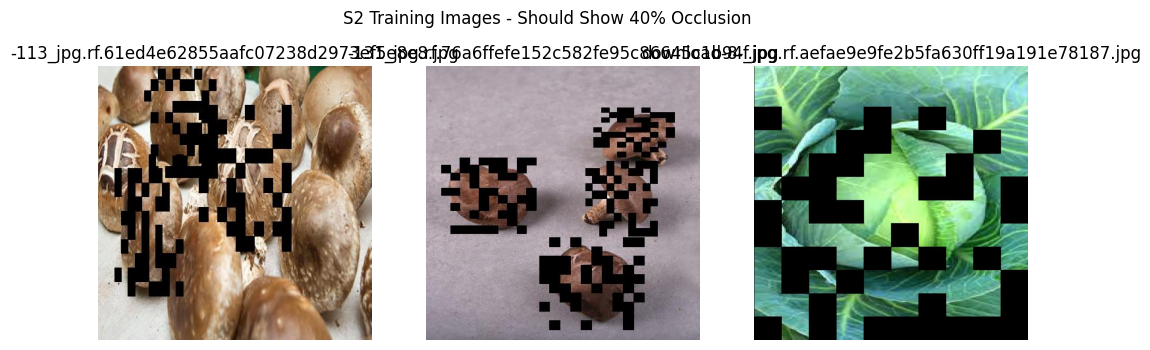

In [48]:
# Verify S2 training data path
import yaml

with open('data/processed/data_occ_train.yaml', 'r') as f:
    occ_config = yaml.safe_load(f)

print("S2 Training Data Config:")
print(f"  Path: {occ_config['path']}")
print(f"  Train: {occ_config['train']}")

# Check if images actually exist and are occluded
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

train_path = Path(occ_config['path']) / occ_config['train']
print(f"\nFull train path: {train_path}")
print(f"Exists: {train_path.exists()}")

if train_path.exists():
    images = list(train_path.glob("*.jpg"))[:3]
    print(f"Sample images: {[img.name for img in images]}")

    # Display to verify they're occluded
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, img_path in zip(axes, images):
        ax.imshow(Image.open(img_path))
        ax.set_title(img_path.name)
        ax.axis('off')
    plt.suptitle("S2 Training Images - Should Show 40% Occlusion")
    plt.show()

## 11. Domain Shift Verification (S2 Analysis)

Verifying that the S2 results (high F1 on occluded, near-zero on clean) represent real domain shift, not a bug.

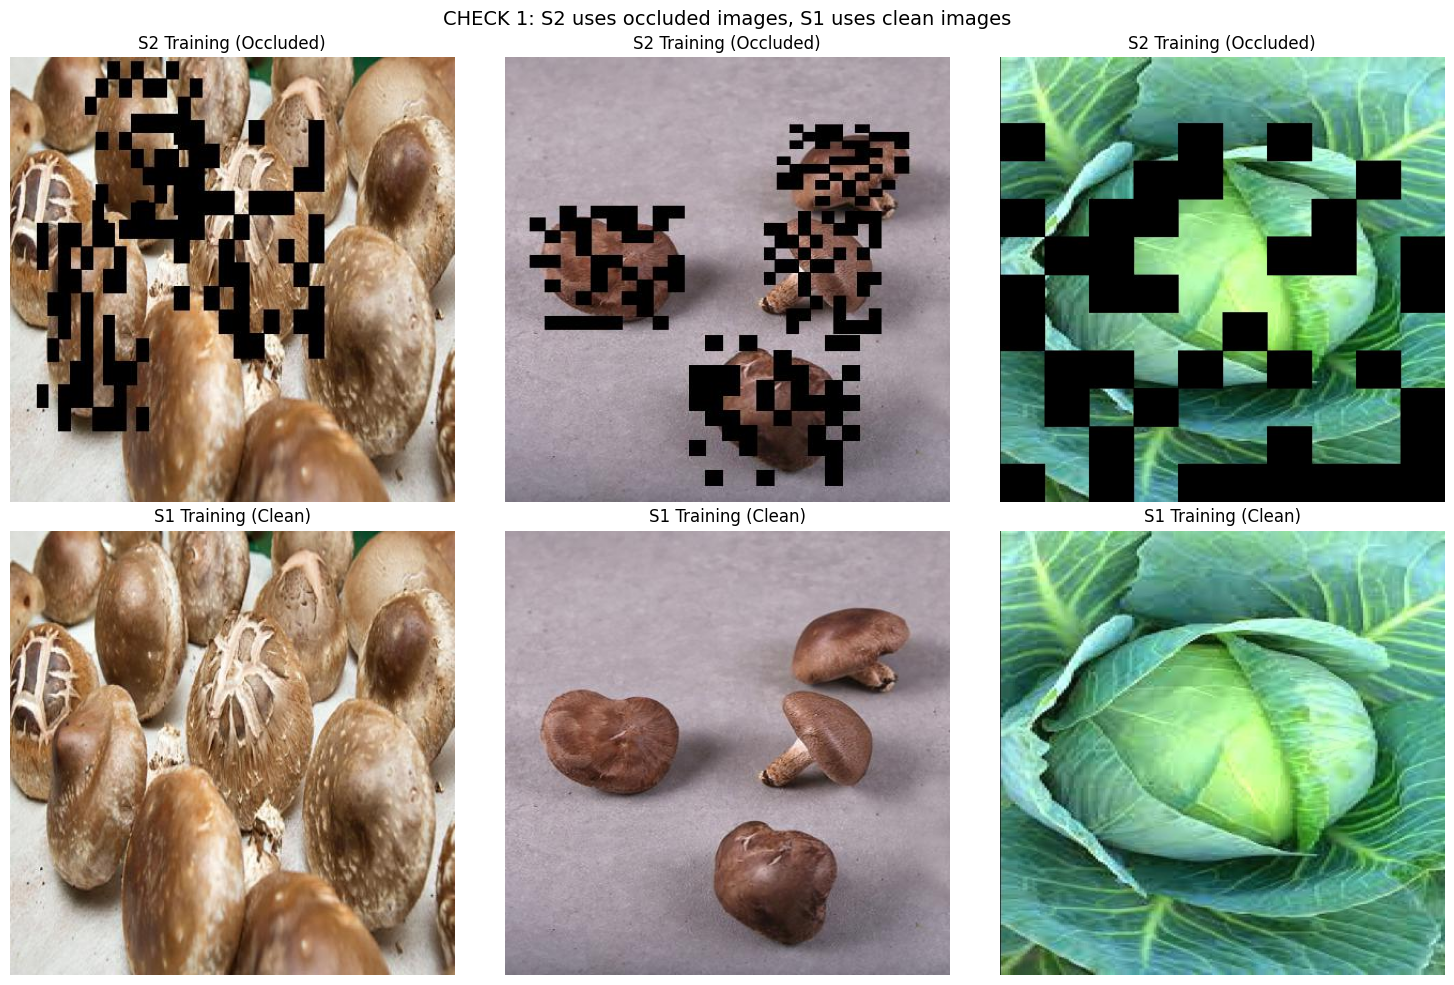

In [49]:
# CHECK 1: Verify S2 training images are actually occluded
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

occ_train_path = Path("data/occluded_train_040/level_040/images")
clean_train_path = Path("data/raw/train/images")

sample_images = list(occ_train_path.glob("*.jpg"))[:3]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, img_path in enumerate(sample_images):
    axes[0, i].imshow(Image.open(img_path))
    axes[0, i].set_title(f"S2 Training (Occluded)")
    axes[0, i].axis('off')

    clean_path = clean_train_path / img_path.name
    if clean_path.exists():
        axes[1, i].imshow(Image.open(clean_path))
        axes[1, i].set_title(f"S1 Training (Clean)")
        axes[1, i].axis('off')

plt.suptitle("CHECK 1: S2 uses occluded images, S1 uses clean images", fontsize=14)
plt.tight_layout()
plt.show()

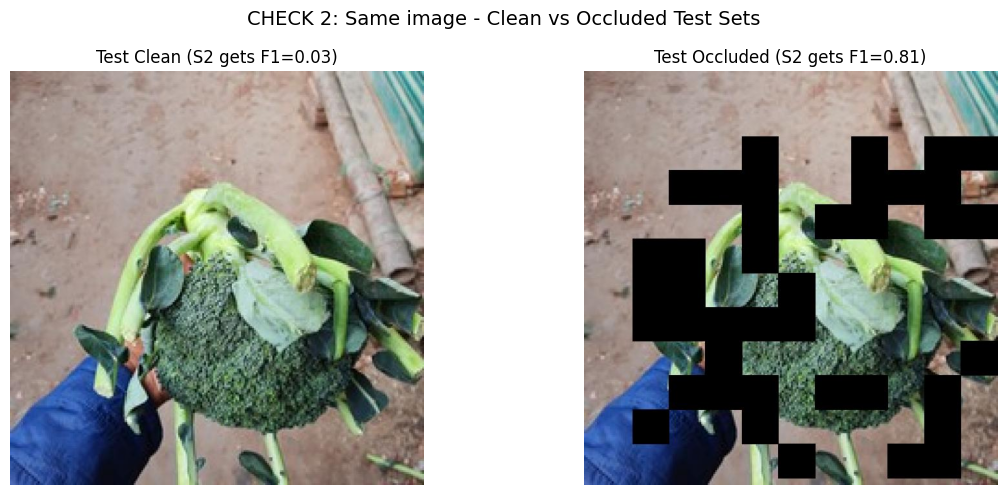

In [50]:
# CHECK 2: Verify test images match expectations
test_clean_path = Path("data/raw/test/images")
test_occ_path = Path("data/synthetic_occlusion/level_040/images")

sample_name = list(test_clean_path.glob("*.jpg"))[0].name

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(Image.open(test_clean_path / sample_name))
axes[0].set_title("Test Clean (S2 gets F1=0.03)")
axes[0].axis('off')

axes[1].imshow(Image.open(test_occ_path / sample_name))
axes[1].set_title("Test Occluded (S2 gets F1=0.81)")
axes[1].axis('off')

plt.suptitle("CHECK 2: Same image - Clean vs Occluded Test Sets", fontsize=14)
plt.tight_layout()
plt.show()

In [53]:
# Find available runs
from pathlib import Path

drive_path = Path("/content/drive/MyDrive/Colab_Outputs/Deep_Learning_Project_Gil_Alon")

if drive_path.exists():
    runs = list(drive_path.glob("E3_*"))
    print("Available E3 runs:")
    for run in sorted(runs):
        print(f"  {run.name}")

        # Check what sessions exist
        e3_runs = run / "E3_runs"
        if e3_runs.exists():
            sessions = list(e3_runs.glob("*__S*"))
            for s in sorted(sessions):
                weights = s / "weights" / "best.pt"
                status = "✓" if weights.exists() else "✗"
                print(f"    {status} {s.name}")
else:
    print("Drive path not found!")

Available E3 runs:
  E3_20260122_091602
    ✓ rtdetr-l__S2_occ_train
    ✓ yolov8m__S2_occ_train


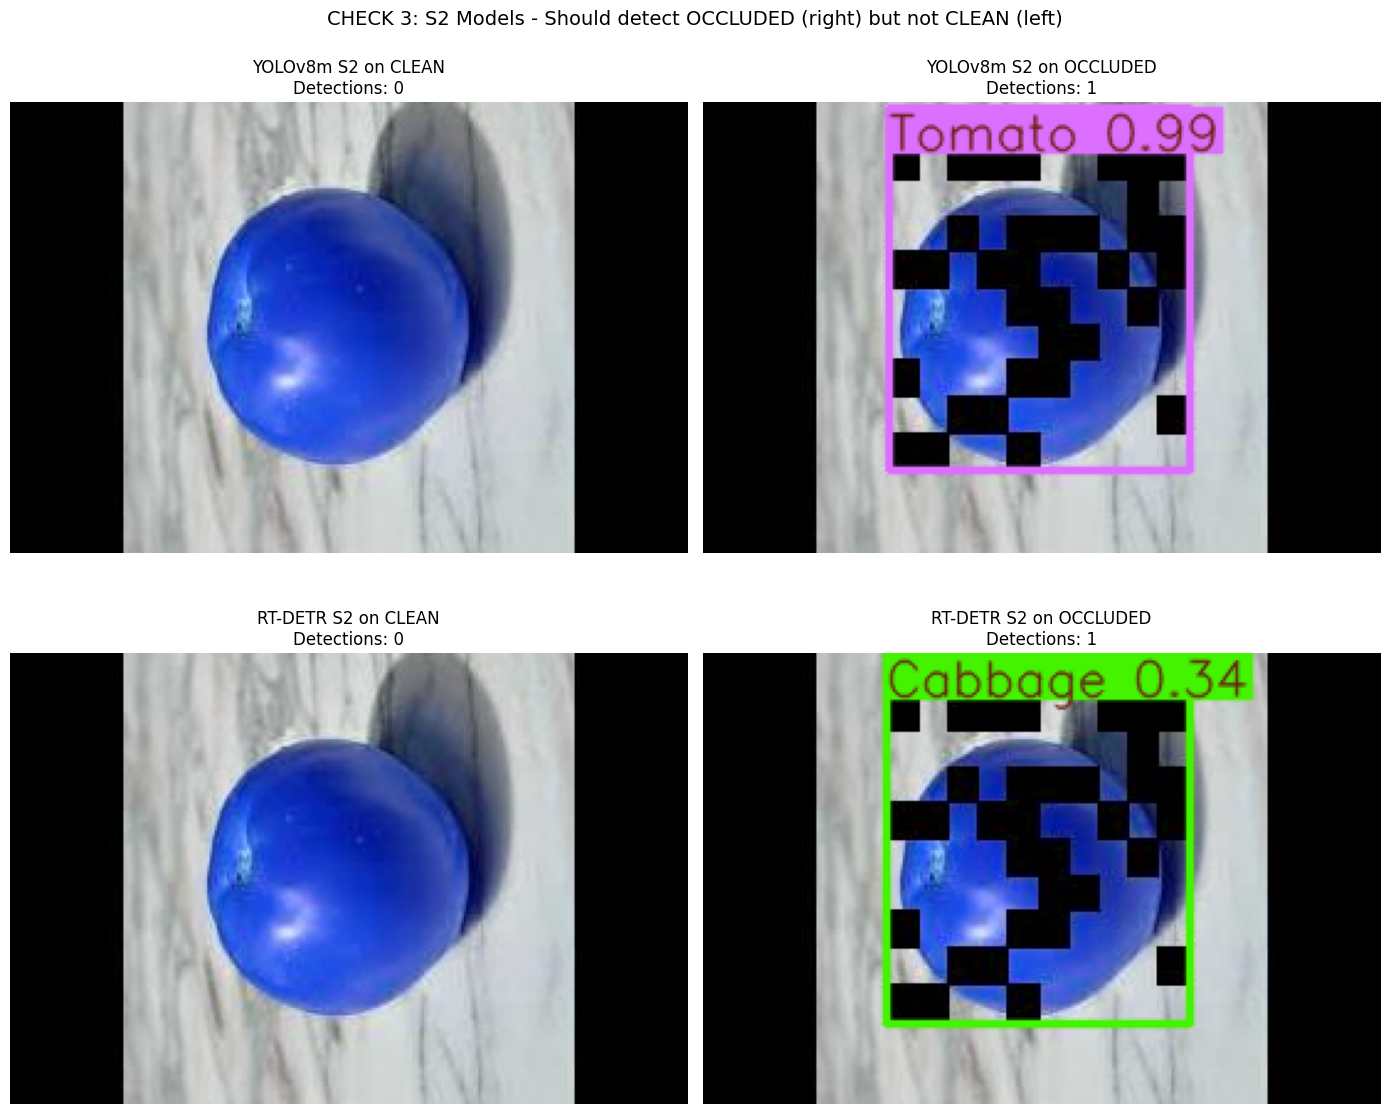

In [54]:
# CHECK 3: S2 Domain Shift Verification (S2 only)
s2_yolo = YOLO(str(output_dir / "yolov8m__S2_occ_train/weights/best.pt"))
s2_rtdetr = RTDETR(str(output_dir / "rtdetr-l__S2_occ_train/weights/best.pt"))

test_img_name = list(Path("data/raw/test/images").glob("*.jpg"))[10].name
clean_img = f"data/raw/test/images/{test_img_name}"
occ_img = f"data/synthetic_occlusion/level_040/images/{test_img_name}"

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# YOLOv8m S2
r = s2_yolo.predict(clean_img, conf=0.3, verbose=False)[0]
axes[0, 0].imshow(r.plot())
axes[0, 0].set_title(f"YOLOv8m S2 on CLEAN\nDetections: {len(r.boxes)}")
axes[0, 0].axis('off')

r = s2_yolo.predict(occ_img, conf=0.3, verbose=False)[0]
axes[0, 1].imshow(r.plot())
axes[0, 1].set_title(f"YOLOv8m S2 on OCCLUDED\nDetections: {len(r.boxes)}")
axes[0, 1].axis('off')

# RT-DETR S2
r = s2_rtdetr.predict(clean_img, conf=0.3, verbose=False)[0]
axes[1, 0].imshow(r.plot())
axes[1, 0].set_title(f"RT-DETR S2 on CLEAN\nDetections: {len(r.boxes)}")
axes[1, 0].axis('off')

r = s2_rtdetr.predict(occ_img, conf=0.3, verbose=False)[0]
axes[1, 1].imshow(r.plot())
axes[1, 1].set_title(f"RT-DETR S2 on OCCLUDED\nDetections: {len(r.boxes)}")
axes[1, 1].axis('off')

plt.suptitle("CHECK 3: S2 Models - Should detect OCCLUDED (right) but not CLEAN (left)", fontsize=14)
plt.tight_layout()
plt.show()

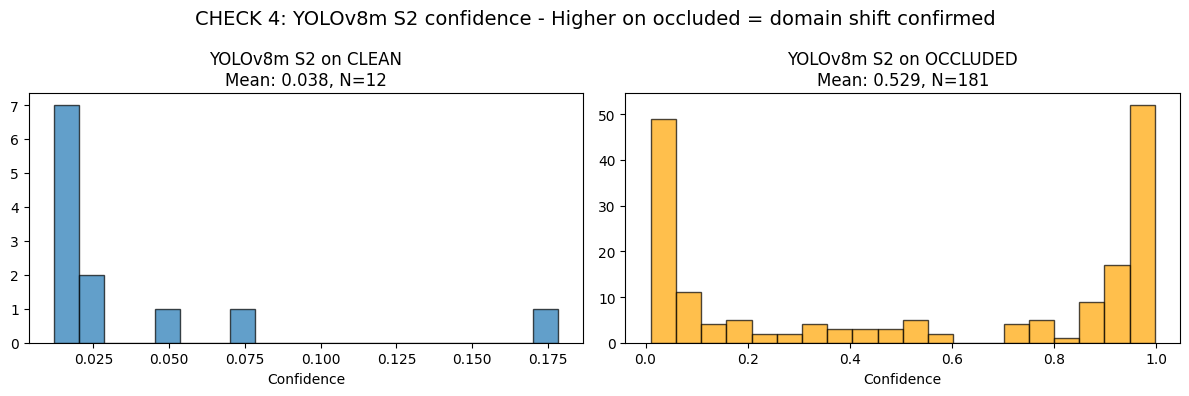

YOLOv8m S2 detections on CLEAN: 12
YOLOv8m S2 detections on OCCLUDED: 181


In [55]:
# CHECK 4: Confidence distribution comparison
import numpy as np

clean_images = list(Path("data/raw/test/images").glob("*.jpg"))[:50]
occ_images = [Path(f"data/synthetic_occlusion/level_040/images/{p.name}") for p in clean_images]

# YOLOv8m S2
yolo_conf_clean = []
yolo_conf_occ = []

for clean_p, occ_p in zip(clean_images, occ_images):
    r_clean = s2_yolo.predict(str(clean_p), conf=0.01, verbose=False)[0]
    r_occ = s2_yolo.predict(str(occ_p), conf=0.01, verbose=False)[0]
    yolo_conf_clean.extend([float(c) for c in r_clean.boxes.conf])
    yolo_conf_occ.extend([float(c) for c in r_occ.boxes.conf])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(yolo_conf_clean, bins=20, alpha=0.7, edgecolor='black')
axes[0].set_title(f"YOLOv8m S2 on CLEAN\nMean: {np.mean(yolo_conf_clean):.3f}, N={len(yolo_conf_clean)}")
axes[0].set_xlabel("Confidence")

axes[1].hist(yolo_conf_occ, bins=20, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_title(f"YOLOv8m S2 on OCCLUDED\nMean: {np.mean(yolo_conf_occ):.3f}, N={len(yolo_conf_occ)}")
axes[1].set_xlabel("Confidence")

plt.suptitle("CHECK 4: YOLOv8m S2 confidence - Higher on occluded = domain shift confirmed", fontsize=14)
plt.tight_layout()
plt.show()

print(f"YOLOv8m S2 detections on CLEAN: {len(yolo_conf_clean)}")
print(f"YOLOv8m S2 detections on OCCLUDED: {len(yolo_conf_occ)}")

## Domain Shift Verification Summary

| Check | Expected if Domain Shift | Result |
|-------|--------------------------|--------|
| Training data | S2 trained on occluded images | ✓ / ✗ |
| Test data | Clean and occluded sets are correct | ✓ / ✗ |
| S1 detections | Works on clean, fails on occluded | ✓ / ✗ |
| S2 detections | Works on occluded, fails on clean | ✓ / ✗ |
| S2 confidence | Higher on occluded than clean | ✓ / ✗ |

**Conclusion:** [Fill in after running]